In [1]:
import glob, os, json, re, io
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.stats as ss
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans, AgglomerativeClustering
from statannotations.Annotator import Annotator

sns.set_context('talk')
import warnings

import importlib
import myutil
importlib.reload(myutil)
from myutil import *

# Suppress warnings
warnings.filterwarnings('ignore')

In [2]:
# define colors here
outcome_palette = {'win':'#daa520', 'lose':"#bf00ff"}
outcome_colors = ['#daa520', "#bf00ff"] #win, lose
compromise_palette = {'high':'firebrick', 'low':'steelblue'}
compromise_colors = ['firebrick', 'steelblue'] #high, low
risk_palette = {'risk-averse': 'teal', 'risk-prone': 'salmon'}
risk_colors = ['teal', 'salmon'] #high, low

# Read Data

In [3]:
## determine which batch to plot
folder = 'expl'
# folder = 'conf'

## define where to save figures
save = True

# save = False

In [4]:
# # # #if expl
if folder == 'expl':
    df_group = pd.read_csv('../processed_data/parsed_group_expl.csv')
    df_idv = pd.read_csv('../processed_data/parsed_idv_expl.csv')
    print(f"{len(df_group['room'].unique())} rooms in total with {len(df_group['subID'].unique())} subjects")
else:
    df_group = pd.read_csv('../processed_data/parsed_group_rep2.csv')
    df_group['player_partner_diff'] = df_group['playerStep'] - df_group['partnerStep']
    df_idv_all = pd.read_csv('../processed_data/parsed_idv_rep2.csv')
    # df_idv_all = df_idv_all.drop('attack.1' , axis=1)
    df_idv_all['subID'] = df_idv_all['subID'] + 400
    df_idv = df_idv_all.query('trial <=120')
    df_idv2 = df_idv_all.query('trial >120')

    # print(f"{len(df_group['room'].unique())} rooms in total")
    # print(f"{len(df_idv['sub'].unique())} subjects in total")
    df_group['room'] = df_group['room'] + 200
    df_group['subID'] = df_group['subID'] + 400
    df_group['jointMoney'] = df_group.apply(lambda x: -20 if x['attack'] else x['jointMoney'], axis=1)

    df_group = pd.concat([df_group, 
                      pd.read_csv('../processed_data/parsed_group_conf.csv')])
    # df_group = df_group.query('room !=52 and room != 72')
    df_idv = pd.concat([df_idv, 
                        pd.read_csv('../processed_data/parsed_idv_conf.csv')])
    # df_idv = df_idv.query('sub != "665a00"')
    # qs = pd.read_csv('../processed_data/parsed_questionnaire_all.csv')
    print(f"{len(df_group['room'].unique())} rooms in total")
    print(f"{len(df_idv['subID'].unique())} subjects in total")
    
df_group = df_group[['block', 'trial', 'room', 'subID', 'attack', 'selfBlame', 'jointMoney', 'partnerStep', 'playerStep', 'prediction', 'step_rt', 'predatorType', 'player_partner_diff', 'finalStep', 'playerID', 'confidence']]
num_subs = len(df_idv['subID'].unique())


125 rooms in total with 250 subjects


In [5]:
# c = pd.merge(df_group.query('predatorType==1').groupby(['room'], as_index=False)['playerStep'].mean(), 
#          df_group.query('predatorType==0').groupby(['room'], as_index=False)['playerStep'].mean(),
#          on='room')
# c.query('playerStep_x > playerStep_y')

In [6]:
#add partner blame
df_group['partnerBlame'] = df_group.groupby(['room', 'trial', 'predatorType'])['selfBlame'].shift()
g = df_group.groupby(['room', 'trial', 'predatorType'])['selfBlame']
df_group['partnerBlame'] = g.shift(1).fillna(g.shift(-1))
#add prediciton error
df_group['abs_pred_error'] = np.abs(df_group['prediction'] - df_group['partnerStep'])
#add paredator and num_encounter
df_idv['predator'] = df_idv['predatorType'].apply(lambda x: 'low-threat' if x==0 else 'high-threat')
df_idv['num_encounter'] =  df_idv.groupby(['subID', 'predatorType'])['trial'].cumcount() + 1
df_group['predator'] = df_group['predatorType'].apply(lambda x: 'low-threat' if x==0 else 'high-threat')
#add outcome
df_group['outcome'] = df_group.apply(lambda row: 'harvest' if (row['attack']==0) else 'captured', axis=1).astype('category')
df_group['outcome'] = df_group['outcome'].cat.reorder_categories(['harvest', 'captured'], ordered=True)


In [7]:
c = df_idv.groupby(['subID'])['trial'].count()
c[c>120]

Series([], Name: trial, dtype: int64)

In [8]:
# c = df_group.loc[df_group.step_rt==8].groupby(['sub', 'room'])['trial'].count()
# c[c>=20]
#are there people who played twice?
c = df_group.groupby(['subID'])['room'].apply(lambda x: len(np.unique(x)))
subs = c[c>1].index
#you may want to remove room 52/58, room 72/78
df_group.query('subID in @subs')[['subID', 'room']].drop_duplicates()

,subID,room


In [9]:
# subs = df_group['sub'].unique()
# id_mappings = dict(zip(subs, np.arange(len(subs))))
# df_group['sub'] = df_group['sub'].apply(lambda x: id_mappings[x])
# df_idv = df_idv.query('sub in @subs')
# df_idv['sub'] = df_idv['sub'].apply(lambda x: id_mappings[x])
# print(f"{len(df_group['room'].unique())} rooms in total")


In [10]:
# save regression results to a table in img format
def save_reg_to_table(change_model, num_betas, change_formula, title, folder=folder):
    rdf = results_to_df(change_model, num_betas)
    rdf = format_df_for_print(rdf,)
    df_to_png(rdf, change_formula, title, folder)


# Fig1 Location Choice

[500, 500]


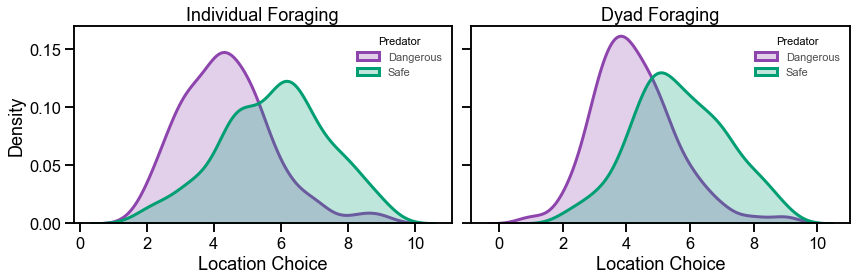

idv safe: m= 5.79584,       se=0.1002751721591117
idv dangerous: m= 4.378098412698413,       se=0.08683955743339633
group safe: m= 5.654767800556376,       se=0.09361587573289086
group dangerous: m= 4.268886132637043,       se=0.0840695322500436
Safe Predator: t-value = 1.028354085409741, p-value = 0.30428250194775297
Dangerous Predator: t-value = 0.9035751466146988, p-value = 0.36665758858768327
keep 245 (room, predator)
RA: dyad vs idv step:TtestResult(statistic=3.953936104611489, pvalue=0.00010076447773808404, df=244)
RP: dyad vs idv step: TtestResult(statistic=-7.582635983670384, pvalue=7.072442444882071e-13, df=244)


In [11]:
#is there a difference in location choice between different predators?
#in both group and individual condition
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# gg = df_group.groupby(['sub', 'room', 'predatorType'], as_index=False)[['finalStep', 'playerStep']].mean()
# gi = df_idv.loc[df_idv.trial>60].groupby(['sub', 'predatorType'], as_index=False)['choice'].mean()
# sns.barplot(data=gi, x='predatorType', y='choice', ax=axes[0])
# axes[0].set_ylabel('individual choice')
# sns.barplot(data=gg, x='predatorType', y='playerStep', ax=axes[1])
# #sns.swarmplot(data=gg, x='predatorType', y='stepChoice', ax=axes[1])
# axes[1].set_ylabel('group choice')
# axes[0].set_xticklabels(['safe', 'dangerous'])
# axes[1].set_xticklabels(['safe', 'dangerous'])


# Set the font for the plot
plt.rcParams['font.family'] = 'Arial'  


def get_predator_colors():
    return {0: "#009E73", 1: "#8E44AD"}  # Teal and Dark Purple

# Apply colors using the defined function
predator_colors = get_predator_colors()

# Create the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Data processing for individual and group foraging
gg = df_group.query('step_rt<8 and playerStep>0').groupby(['subID', 'room', 'predatorType'], 
                  as_index=False)[['finalStep', 'playerStep', 'jointMoney']].mean()
gi = df_idv.query('trial>60').groupby(['subID', 'predatorType'], as_index=False)[['choice', 'reward']].mean()
# gi = df_idv2.groupby(['sub', 'predatorType'], as_index=False)[['choice', 'reward']].mean()
print([len(gg), len(gi)])
# Plot for individual foraging
sns.kdeplot(data=gi, hue='predatorType', x='choice', ax=axes[0], fill=True, palette=predator_colors, 
             linewidth=3)
axes[0].set_title('Individual Foraging')
axes[0].set_xlabel('Location Choice')
axes[0].legend(['Dangerous', 'Safe'], title='Predator', fontsize=11, frameon=False, 
               facecolor='darkgrey', labelcolor='#4D4D4D', 
               )
##decrease font of legend title
axes[0].get_legend().get_title().set_fontsize('11')

# Plot for group foraging
sns.kdeplot(data=gg, hue='predatorType', x='playerStep', ax=axes[1], fill=True, palette=predator_colors, 
            linewidth=3)
axes[1].set_title('Dyad Foraging')
axes[1].set_xlabel('Location Choice')
axes[1].legend(['Dangerous', 'Safe'], title='Predator', fontsize=11, frameon=False, 
               facecolor='darkgrey', labelcolor='#4D4D4D', 
               )
##decrease font of legend title
axes[1].get_legend().get_title().set_fontsize('11')

# Tight layout for better spacing
plt.tight_layout()
plt.show()


# print mean and sem
print(f"idv safe: m= {np.mean(gi.query('predatorType==0')['choice'])}, \
      se={ss.sem(gi.query('predatorType==0')['choice'])}")
print(f"idv dangerous: m= {np.mean(gi.query('predatorType==1')['choice'])}, \
      se={ss.sem(gi.query('predatorType==1')['choice'])}")
print(f"group safe: m= {np.mean(gg.query('predatorType==0')['playerStep'])}, \
      se={ss.sem(gg.query('predatorType==0')['playerStep'])}")
print(f"group dangerous: m= {np.mean(gg.query('predatorType==1')['playerStep'])}, \
      se={ss.sem(gg.query('predatorType==1')['playerStep'])}")


##do t-test between individual and group foraging for each predator type
# Perform t-test for safe predator
ttest_safe = ss.ttest_ind(gi.query('predatorType==0')['choice'], gg.query('predatorType==0')['playerStep'])
# Perform t-test for dangerous predator
ttest_dangerous = ss.ttest_ind(gi.query('predatorType==1')['choice'], gg.query('predatorType==1')['playerStep'])
print(f"Safe Predator: t-value = {ttest_safe.statistic}, p-value = {ttest_safe.pvalue}")
print(f"Dangerous Predator: t-value = {ttest_dangerous.statistic}, p-value = {ttest_dangerous.pvalue}")

# get group stats
group_stat = get_riskiness_wpair_by_predator_type(gi, gg)
group_stat_filtered = filter_groups_by_riskiness(group_stat)
# print(ss.ttest_rel(group_stat_filtered['individual'], group_stat_filtered['group']))

# print ttest
ra = group_stat_filtered.query('risky_wpair=="risk-averse"')
print(f"RA: dyad vs idv step:{ss.ttest_rel(ra['group'],ra['individual'])}")
rp = group_stat_filtered.query('risky_wpair=="risk-prone"')
print(f"RP: dyad vs idv step: {ss.ttest_rel(rp['group'], rp['individual'])}")

## ttest on idv vs group step for RA and RP
with open(f"../model_fits/regs/ttest_compromise_{folder}.txt", "w") as f:
     f.write(f"idv safe: m= {np.mean(gi.query('predatorType==0')['choice'])}, \
             se={ss.sem(gi.query('predatorType==0')['choice'])}\n")
     f.write(f"idv dangerous: m= {np.mean(gi.query('predatorType==1')['choice'])}, \
             se={ss.sem(gi.query('predatorType==1')['choice'])}\n")
     f.write(f"group safe: m= {np.mean(gg.query('predatorType==0')['playerStep'])}, \
             se={ss.sem(gg.query('predatorType==0')['playerStep'])}\n")
     f.write(f"group dangerous: m= {np.mean(gg.query('predatorType==1')['playerStep'])}, \
              se={ss.sem(gg.query('predatorType==1')['playerStep'])}\n")
     f.write(f"RA: dyad vs idv step:{ss.ttest_rel(ra['group'],ra['individual'])}\n")
     f.write(f"RP: dyad vs idv step: {ss.ttest_rel(rp['group'], rp['individual'])}\n")
# group_stat['diff'] = group_stat['individual'] - group_stat['group']
# # print(ss.ttest_ind(group_stat['diff'], 0))


# ##ttest of diff between group and idv for each predator type
# print(ss.ttest_ind(group_stat.query('predatorType==0')['diff'], 0))
# print(ss.ttest_ind(group_stat.query('predatorType==1')['diff'], 0))



In [12]:

def visualize_raw_data(g):
    fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)  
    plt.subplots_adjust(hspace=0.4)

    x_map = {'individual': 0, 'group': 1}

    for i, pred_type in enumerate([0, 1]):
        ax = axes[i]
        
        # Subset and sort
        data = g.loc[g.predatorType == pred_type].sort_values(by=['room', 'risky_wpair'])
        
        # Melt data
        melted_data = data[['subID', 'risky_wpair', 'individual', 'group']].melt(
            id_vars=['subID', 'risky_wpair'], 
            value_vars=['individual', 'group'], 
            var_name='variable', 
            value_name='value'
        )
        
        # Map variable to numeric + jitter
        noise = 0.05
        melted_data['y_jittered'] = melted_data['variable'].map(x_map) + \
                                    np.random.normal(0, noise, size=melted_data.shape[0])

        for phase, y_value in x_map.items():
            for order in risk_palette.keys():
                subset = melted_data[(melted_data['variable'] == phase) & (melted_data['risky_wpair'] == order)]
                
                kde = sns.kdeplot(subset['value'], linewidth=0, common_norm=False, color='gray', ax=ax)

                x_vals = kde.lines[-1].get_xdata()
                y_vals = kde.lines[-1].get_ydata()
                offset = noise * 2

                if phase == "individual":
                    ax.fill_betweenx(y=y_value - y_vals * 0.7 - offset,
                                     x1=x_vals, x2=y_value - offset,
                                     alpha=0.1, color=risk_palette[order])
                elif phase == "group":
                    ax.fill_betweenx(y=y_value + y_vals * 0.7 + offset,
                                     x1=x_vals, x2=y_value + offset,
                                     alpha=0.1, color=risk_palette[order])

        # Line plot
        sns.lineplot(data=melted_data, y='y_jittered', x='value', hue='risky_wpair',
                     units='subID', estimator=None, ax=ax, 
                     palette=risk_palette, linewidth=0.2, alpha=0.4, legend=False)

        # Scatter plot
        sns.scatterplot(data=melted_data, y='y_jittered', x='value', hue='risky_wpair',
                        palette=risk_palette, s=20, ax=ax, legend=False, alpha=0.4)

        # Pointplot for means
        sns.pointplot(data=melted_data, y='variable', x='value', hue='risky_wpair',
                      palette=risk_palette, scale=1, ax=ax, ci=95, dodge=0.1, legend=False)

        # Set yticks as phase labels
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['Individual', 'Dyad'], rotation=90, va='center', fontsize=19)

        # Axis labels
        ax.set_ylabel('')
        ax.set_xlabel('Foraging Step', labelpad=15, fontsize=19)

        # Axis limits
        ax.set_xlim(0.5, 9.5)

    # Titles
    axes[0].set_title('Low-Threat Predator', fontsize=20)
    # axes[0].set_facecolor('orange')
    # axes[0].patch.set_alpha(0.05)
    axes[1].set_title('High-Threat Predator', fontsize=20)
    # axes[1].set_facecolor('blue')
    # axes[1].patch.set_alpha(0.05)

    # Custom legend
    legend_handles = [
        Line2D([0], [0], color='w', markerfacecolor=risk_palette['risk-averse'], 
               markersize=10, marker='o', label='risk-averse'),
        Line2D([0], [0], color='w', markerfacecolor=risk_palette['risk-prone'], 
               markersize=10, marker='o', label='risk-prone')
    ]
    fig.legend(handles=legend_handles, title='Riskiness within Dyad', ncol=2, 
               bbox_to_anchor=(0.9, 0.074), frameon=True, fontsize=13, title_fontsize=13)

    # plt.tight_layout()
    if save:
        plt.savefig(f'../paper_figs/{folder}/behavior_{folder}.png', 
                bbox_inches='tight', dpi=200)


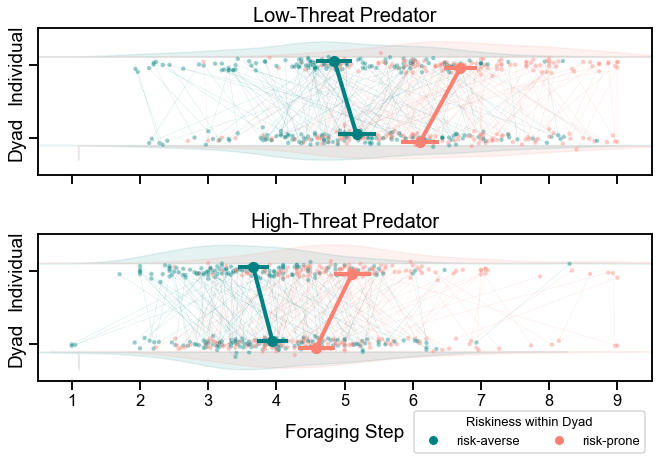

In [13]:

visualize_raw_data(group_stat_filtered)

                     sum_sq     df         F    PR(>F)
C(predatorType)    2.225362    1.0  3.256776  0.071746
C(risky_wpair)     0.000502    1.0  0.000735  0.978380
Residual         332.768215  487.0       NaN       NaN
TtestResult(statistic=0.027051228451729588, pvalue=0.9784299330203308, df=488.0)


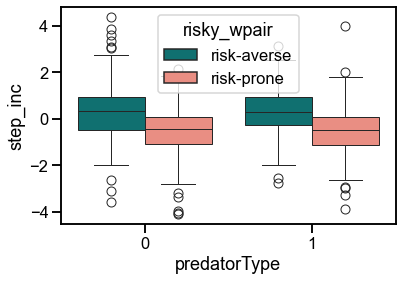

In [14]:
#compare money increase between risky and risk-averse individuals
# group_stat_filtered = filter_groups_by_riskiness(group_stat)
sns.boxplot(data=group_stat_filtered, y='step_inc', x='predatorType', hue='risky_wpair', palette=risk_palette)

#run a anova - no obvious difference between predator type and riskiness
group_stat_filtered['abs_step_inc'] = np.abs(group_stat_filtered['step_inc'])
model = smf.ols('abs_step_inc ~ C(predatorType) + C(risky_wpair)', data=group_stat_filtered)
anova_table = sm.stats.anova_lm(model.fit(), typ=2)
print(anova_table)

#then t-test
print(ss.ttest_ind(group_stat_filtered.query('risky_wpair=="risk-averse"')['abs_step_inc'], 
                   group_stat_filtered.query('risky_wpair=="risk-prone"')['abs_step_inc'],))
# print(ss.ttest_1samp(group_stat_filtered.query('risky_wpair=="risk-averse"')['step_inc'], 0))
# sample =group_stat_filtered.query('risky_wpair=="risk-prone"')['step_inc']
# mean_diff = 0 - np.mean(sample)  # or just np.mean(sample)
# std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
# cohens_d = mean_diff / std_dev
# print(f"Cohen's d for risk-averse: {cohens_d}")

# print(ss.ttest_1samp(group_stat_filtered.query('risky_wpair=="risk-prone"')['step_inc'], 0))
# sample = group_stat_filtered.query('risky_wpair=="risk-prone"')['step_inc']
# mean_diff = 0 - np.mean(sample)  # or just np.mean(sample)
# std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
# cohens_d = mean_diff / std_dev
# print(f"Cohen's d for risk-prone: {cohens_d}")

## overall compromise

In [15]:
# group_stat = pd.merge(group_stat, df_group.query('selfBlame>0').groupby(['subID'], as_index=False)['selfBlame'].mean())
# model = smf.ols('selfBlame ~ C(predatorType) + C(risky_wpair)', data=group_stat)
# anova_table = sm.stats.anova_lm(model.fit(), typ=2)
# print(anova_table)


ego_bias = df_group.query('selfBlame>0').groupby(['subID', 'attack', 'predatorType'], as_index=False)['selfBlame'].mean()
# ego_bias = pd.merge(ego_bias.query('attack==True'), ego_bias.query('attack==False'), on=['subID', 'predatorType'], suffixes=['_lose', '_win'])
# ego_bias['ego_bias'] = ego_bias['selfBlame_win'] - ego_bias['selfBlame_lose']
# ego_bias = pd.merge(ego_bias, group_stat)
# model = smf.ols('ego_bias ~ C(predatorType) + C(risky_wpair)', data=ego_bias)
model = smf.ols('selfBlame ~ C(predatorType) + C(attack)', data=ego_bias)
anova_table = sm.stats.anova_lm(model.fit(), typ=2)
print(anova_table)

                    sum_sq     df          F        PR(>F)
C(predatorType)   0.000902    1.0   0.059532  8.072873e-01
C(attack)         0.667178    1.0  44.038238  5.286858e-11
Residual         15.043913  993.0        NaN           NaN


PearsonRResult(statistic=-0.4352081424754768, pvalue=5.528007784156258e-25)


<Figure size 864x288 with 0 Axes>

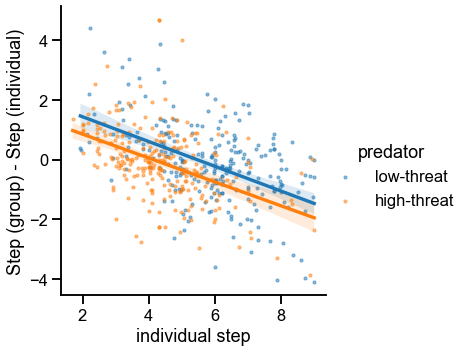

In [16]:
plt.figure(figsize=(12, 4))
sns.lmplot(data = group_stat, x='individual', y='step_inc', hue='predator',
           scatter_kws={'s':10, 'alpha':0.5})
plt.ylabel('Step (group) - Step (individual)')
plt.xlabel('individual step')
print(ss.pearsonr(group_stat['individual'], group_stat['step_inc']))
#sns.regplot(data = g.loc[g.predatorType==1], x='individual', y='grp_idv_step_diff')

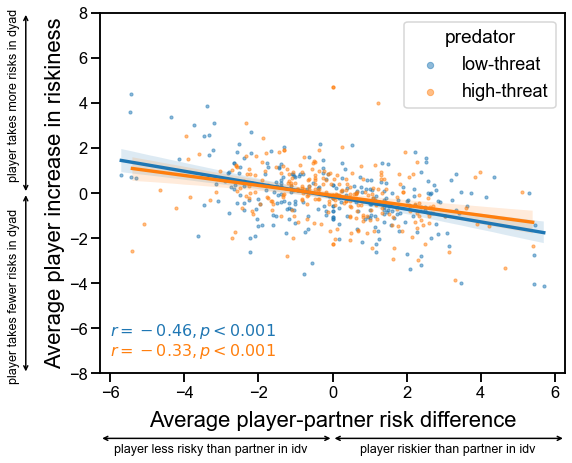

In [17]:
group_stat['self_partner_risk_diff'] = group_stat.groupby(['room', 'predatorType'])['individual'].diff()
group_stat['self_partner_risk_diff'] = group_stat.groupby(['room', 'predatorType'])['self_partner_risk_diff'].transform(lambda x: x.fillna(-x.iloc[-1]))

# sns.regplot(data = g.query('predatorType==0'), x='self_partner_risk_diff', y='step_inc',
#            scatter=False, label='safe')
# sns.regplot(data = g.query('predatorType==1'), x='self_partner_risk_diff', y='step_inc',
#            scatter=False, label='dangerous')
# plt.ylabel('step (dyad) - step (individual)')
# plt.xlabel('player-partner individual step difference')
myfig = sns.lmplot(data = group_stat, x='self_partner_risk_diff', y='step_inc', hue='predator', 
           scatter_kws={'s':10, 'alpha':0.5}, legend=False, 
           aspect=1.25, height=6) #aspect = width / height
plt.legend(title='predator', fontsize=18, title_fontsize=19, markerscale=2, loc='upper right')

# set x, y label
# plt.ylabel('$player_{dyad} - player_{individual}$')
# plt.xlabel('$player_{individual} - partner_{individual}$')
plt.ylabel('Average player increase in riskiness', fontsize=22)
plt.xlabel('Average player-partner risk difference', labelpad=10, fontsize=22)

# Add a full border (spines) around the plot
for ax in myfig.axes.flat:
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

#test significance
r0, p0 = ss.pearsonr(group_stat.query('predatorType==0')['self_partner_risk_diff'], 
                     group_stat.query('predatorType==0')['step_inc'])
r1, p1 = ss.pearsonr(group_stat.query('predatorType==1')['self_partner_risk_diff'], 
                     group_stat.query('predatorType==1')['step_inc'])

# Annotate plot
plt.ylim([-8, 8])
plt.annotate(f"$r={round(r0, 2)}, p<0.001$", (-6, -6.3), fontsize=16, color='#1F77B4')
plt.annotate(f"$r={round(r1, 2)}, p<0.001$", (-6, -7.2), fontsize=16, color='#FF7F0E')

# add arrows below
ft=12.5
myoffset = 0.04
#for x-axis
y_level =-0.18
plt.annotate('', xy=(0, y_level), xytext=(0.5, y_level), #from (x,y) to (xtext, ytext) relateive to (1,1) picture
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops
            =dict(arrowstyle='<->', lw=1.5))
plt.annotate('', xy=(0.5, y_level), xytext=(1, y_level), 
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.annotate('player less risky than partner in idv', xy=(0.03, y_level-myoffset), 
             xycoords='axes fraction', ha='left', fontsize=ft)
plt.annotate('player riskier than partner in idv', xy=(0.56, y_level-myoffset), 
             xycoords='axes fraction', ha='left', fontsize=ft)
#for y-axis
x_lvl = -0.16
plt.annotate('', xy=(x_lvl, 0.5), xytext=(x_lvl, 1), 
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.annotate('', xy=(x_lvl, 0.5), xytext=(x_lvl, 0), 
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.annotate('player takes more risks in dyad', xy=(x_lvl-myoffset, 0.54), 
             xycoords='axes fraction', ha='left', fontsize=ft, rotation=90)
plt.annotate('player takes fewer risks in dyad', xy=(x_lvl-myoffset, -0.02),
             xycoords='axes fraction', ha='left', fontsize=ft, rotation=90)
if save: 
    plt.savefig(f'../paper_figs/{folder}/grp_reg_{folder}.png', 
                bbox_inches='tight', dpi=200)

PearsonRResult(statistic=-0.21335307145871585, pvalue=0.0006040000844683486)
PearsonRResult(statistic=0.04392637926645347, pvalue=0.4849652541819704)


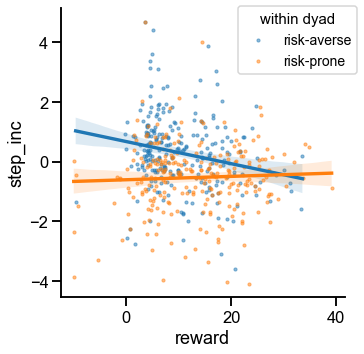

In [18]:
#compromise is independent of performance ..?
sns.lmplot(data=group_stat, y='step_inc', x='reward', hue='risky_wpair', 
           scatter_kws={'s':10, 'alpha':0.5}, legend=None)
plt.legend(title='within dyad', bbox_to_anchor=(0.6, 0.75), fontsize=14, title_fontsize=15)
#test significance
print(ss.pearsonr(group_stat.query('risky_wpair=="risk-averse"')['reward'], 
                    group_stat.query('risky_wpair=="risk-averse"')['step_inc']))
print(ss.pearsonr(group_stat.query('risky_wpair=="risk-prone"')['reward'], 
                    group_stat.query('risky_wpair=="risk-prone"')['step_inc']))

## reward, rt, and prediction error

increase in reward id dyad: 
TtestResult(statistic=5.256729552822356, pvalue=2.1616326360834968e-07, df=509)


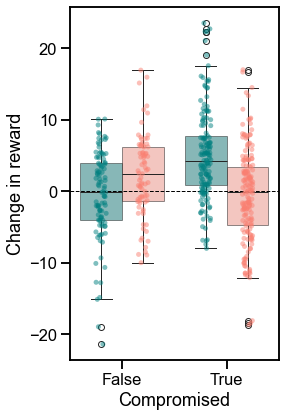

In [19]:
#reward increase by riskiness and predator
plt.figure(figsize=(3.75, 6.5))
group_stat['step_inc_towards_partner']=group_stat.apply(lambda row: row['step_inc'] if row['risky_wpair']=="risk-averse" else -row['step_inc'], axis=1)
group_stat['compromised'] = group_stat['step_inc_towards_partner']>0
group_stat['predator'] = group_stat['predatorType'].apply(lambda x: 'low-threat' if x==0 else 'high-threat')
# sns.swarmplot(data = group_stat, x='compromised', y='reward_inc', hue='risky_wpair', dodge=True, alpha=0.4, s=2,
#               legend=False)
sns.boxplot(data = group_stat, x='compromised', y='reward_inc',
            hue='risky_wpair', palette=risk_palette, 
            flierprops=dict(markersize=6), boxprops=dict(alpha=0.5), )
sns.stripplot(data = group_stat, x='compromised', y='reward_inc', dodge=True,
            hue='risky_wpair', palette=risk_palette, alpha=0.5
)
print("increase in reward id dyad: ")
print(ss.ttest_1samp(group_stat['reward_inc'], 0))
# plt.legend(loc='lower center', fontsize=14, title_fontsize=15, title='riskiness within dyad')
plt.legend().remove()
plt.ylabel('Change in reward')
plt.xlabel('Compromised')
# plt.ylabel(r'$reward_{dyad}$ - $reward_{idv}$')
plt.axhline(y=0, ls='--', color='black', lw=1)

if save:
    plt.savefig(f'../paper_figs/{folder}/reward_by_compromise_{folder}.png', 
            bbox_inches='tight', dpi=200)


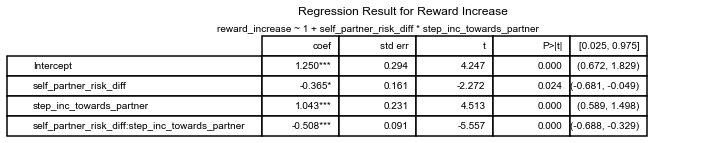

In [20]:

#run regression
# model = smf.ols('reward_inc ~ C(risky_wpair) * C(compromised)', data=group_stat).fit()
reward_model = smf.ols('reward_inc ~ self_partner_risk_diff * step_inc_towards_partner', 
                           data=group_stat).fit()
# model = smf.ols('reward_inc ~ C(predator) * C(compromised)', data=group_stat).fit()

with open(f'../model_fits/regs/reward_reg_summary_continuous_{folder}.txt', "w") as f:
    f.write(reward_model .summary().as_text())

reward_formula = 'reward_increase ~ 1 + self_partner_risk_diff * step_inc_towards_partner'
title = "Regression Result for Reward Increase"
save_reg_to_table(reward_model , 4, reward_formula, title, folder)
# ss.ttest_ind(group_stat.query('risky_wpair=="risk-prone" and predatorType==0')['reward_inc'], 
#                group_stat.query('risky_wpair=="risk-prone" and predatorType==1')['reward_inc'])

(array([ 3.,  6., 22., 36., 56., 64., 36., 22.,  6.,  3.]),
 array([-5.4 , -4.32, -3.24, -2.16, -1.08,  0.  ,  1.08,  2.16,  3.24,
         4.32,  5.4 ]),
 <BarContainer object of 10 artists>)

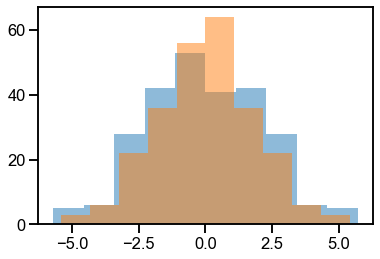

In [21]:
# regress delta_reward on cumulative_reward
# d = group_stat.groupby(['room', 'predatorType'], as_index=False)[['reward', 'reward_inc']].mean()


# sns.lmplot(data=group_stat, y='reward_inc', x='reward', hue='risky_wpair', 
#            scatter_kws={'s':10, 'alpha':0.5}, legend=None)
# sns.lmplot(data=d, y='reward_inc', x='reward', hue='predatorType', 
        #    scatter_kws={'s':10, 'alpha':0.5}, legend=None)
plt.hist(group_stat.query('predatorType==0')['self_partner_risk_diff'], alpha=0.5)
plt.hist(group_stat.query('predatorType==1')['self_partner_risk_diff'], alpha=0.5)

# maybe: dyads with higher risk diff compromise

Text(0, 0.5, 'log (RT)')

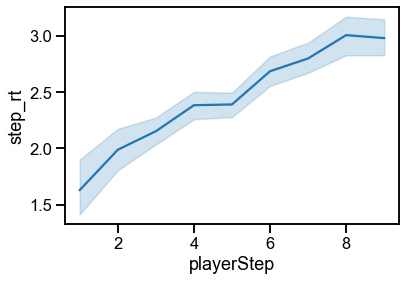

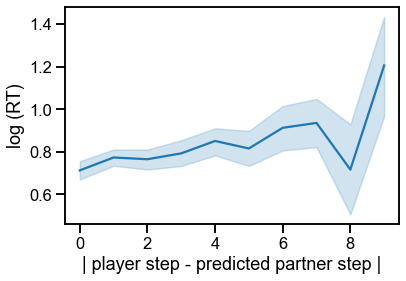

In [22]:
# take a look at rt
d = df_group.query('step_rt<8').groupby(['subID', 'playerStep'], as_index=False)['step_rt'].mean()
sns.lineplot(data = d, x='playerStep', y='step_rt')

plt.figure()
df_group['abs_player_pred_diff']= np.abs(df_group['prediction'] - df_group['playerStep'])
df_group['log_step_rt'] = np.log(df_group['step_rt'])
d = df_group.query('step_rt<8 and abs_player_pred_diff<10').groupby(['subID', 'abs_player_pred_diff'], as_index=False)['log_step_rt'].mean()
sns.lineplot(data = d, x='abs_player_pred_diff', y='log_step_rt')
plt.xlabel('| player step - predicted partner step |')
plt.ylabel('log (RT)')

In [23]:
# run regression on RT
# higher self-prediction discrepency -> longer RT
rt_reg = df_group.query('step_rt<8 and prediction>0').copy()
rt_reg['abs_playerStep_prediction_diff'] = np.abs(rt_reg['playerStep'] - rt_reg['prediction'])
rt_reg['log_step_rt'] = np.log(rt_reg['step_rt'])
rt_model = smf.mixedlm('log_step_rt ~ abs_playerStep_prediction_diff + playerStep', 
                    data = rt_reg,
                    groups = rt_reg['subID'],
                    re_formula = '~ abs_playerStep_prediction_diff + playerStep'
                ).fit()
print(rt_model.summary())

with open(f'../paper_figs/{folder}/rt_reg_summary_{folder}.txt', "w") as f:
    f.write(rt_model.summary().as_text())


                          Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            log_step_rt
No. Observations:            14227              Method:                        REML       
No. Groups:                  250                Scale:                         0.1225     
Min. group size:             10                 Log-Likelihood:                -6026.4571 
Max. group size:             60                 Converged:                     Yes        
Mean group size:             56.9                                                         
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        0.278    0.033  8.325 0.000  0.212  0.343
abs_playerStep_prediction_

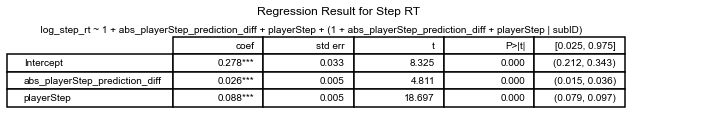

In [24]:
rt_formula = '  log_step_rt ~ 1 + abs_playerStep_prediction_diff + playerStep + (1 + abs_playerStep_prediction_diff + playerStep | subID)'
title = "Regression Result for Step RT"
save_reg_to_table(rt_model, 3, rt_formula, title, folder)

In [25]:
# correlations - no diff early and later
# corr_df1 = (
# df_group.query('trial <= 10 and playerID == 1')
#     .groupby('room')
#     .apply(lambda g: g['playerStep'].corr(g['partnerStep']))
#     .reset_index(name='corr_player_partner')
# )

# corr_df2 = (
# df_group.query('trial > 20 and playerID == 1')
#     .groupby('room')
#     .apply(lambda g: g['playerStep'].corr(g['partnerStep']))
#     .reset_index(name='corr_player_partner')
# )
# corr_df = pd.merge(corr_df1, corr_df2, on=['room'], suffixes=("_early", "_later")).dropna()
# print(ss.ttest_rel(corr_df['corr_player_partner_early'], corr_df['corr_player_partner_later']))


## trial by trial compromise

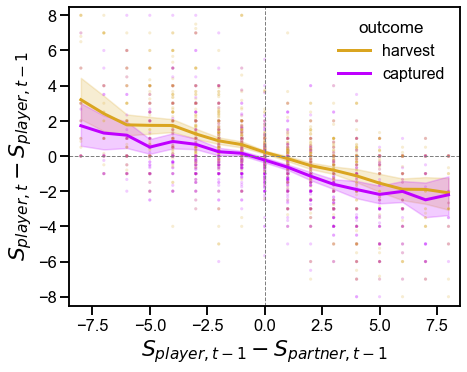

In [26]:
df_cleaned = df_group.sort_values(by=['room', 'block', 'trial'])
df_cleaned['predator'] = df_cleaned['predatorType'].apply(lambda x: 'safe' if x==0 else 'dangerous')
df_cleaned['partner_changed'] = df_cleaned['partnerStep'] - df_cleaned.groupby(['subID', 'block'])['partnerStep'].shift()
df_cleaned['partner_changed_rel'] = df_cleaned['partner_changed'] * np.sign(df_cleaned.groupby(['subID', 'block'])['player_partner_diff'].shift())
df_cleaned['player_change'] = df_cleaned.groupby(['subID', 'block'])['playerStep'].shift(-1) -df_cleaned['playerStep']
df_cleaned['future_step_rt'] = df_cleaned.groupby(['subID', 'block'])['step_rt'].shift(-1)
df_cleaned['player_change_rel'] = -df_cleaned['player_change'] * np.sign(df_cleaned['player_partner_diff'])
df_cleaned = df_cleaned.query('player_change<=8 and player_change>=-8 and player_partner_diff<=8 and player_partner_diff>=-8')
# sns.lmplot(data=df_cleaned, x='partner_changed_rel', y='player_future_change_rel', scatter=False)
# sns.lineplot(data=df_cleaned.groupby(['sub', 'player_partner_diff', 'predator'], as_index=False)['player_change'].mean(), 
#              x='player_partner_diff', y='player_change', hue='predator', hue_order=['safe', 'dangerous'])
# plt.ylim([-6, 6])
# plt.xlabel('player partner step difference')
# plt.ylabel('player step change')


##small plot
plt.figure(figsize=(7, 5.5))

sns.lineplot(data=df_cleaned.groupby(['subID', 'player_partner_diff', 'attack'],
                                     as_index=False)['player_change'].mean(), 
             x='player_partner_diff', y='player_change', hue='attack', 
             linewidth=3,hue_order=[0, 1], palette=outcome_colors,
            )
              
##scatter on top
sns.scatterplot(data=df_cleaned.groupby(['subID', 'player_partner_diff', 'attack'],
                                     as_index=False)['player_change'].mean(),
                x='player_partner_diff',
                y='player_change', hue='attack',
                hue_order=[0, 1], palette=outcome_colors,
                s=10, alpha=0.2)

               
plt.ylim([-8.5, 8.5])
plt.xlim([-8.5, 8.5])
# plt.xlabel('player partner step difference')
# plt.ylabel('player step change')
plt.axhline(0, color='grey', linewidth=1, linestyle='--')
plt.axvline(0, color='grey', linewidth=1, linestyle='--')


##change legend labels by creating two lines of blue and orange
legend_handles=[Line2D([0], [0], color= outcome_colors[0], lw=3),
                Line2D([0], [0], color=outcome_colors[1], lw=3)]

plt.legend(legend_handles, ['harvest', 'captured'], title='outcome', 
           bbox_to_anchor=(0.65, 0.7), fontsize=16, 
           frameon=False,
           title_fontsize=17)



##change x, y labels
# plt.legend().remove()
plt.xlabel(r'$S_{player, t-1} - S_{partner, t-1}$', fontsize=22, labelpad=5)
plt.ylabel(r'$S_{player, t} - S_{player, t-1}$', fontsize=22)

if save:
    plt.savefig(f'../paper_figs/{folder}/trial_reg2_{folder}.png', 
            bbox_inches='tight', dpi=200)

In [27]:
df_cleaned.to_csv(f'../processed_data/reg_{folder}.csv')

In [28]:
# run regression
df_change_reg = df_cleaned.query('trial>1 and trial<30 and step_rt<8 and future_step_rt<8') #remove first and last trial and auto choices
df_change_reg = df_change_reg[['player_change', 'player_partner_diff', 'outcome', 'partner_changed', 'subID', 'trial', 'block', 'partnerStep', 'playerStep']].dropna() #remove first and last trial
print(len(df_change_reg['subID'].unique()))

change_model = smf.mixedlm('player_change ~ player_partner_diff * outcome + partner_changed', 
                    data = df_change_reg,
                    groups = df_change_reg['subID'],
                    re_formula = '~ player_partner_diff * outcome + partner_changed'
                ).fit()
print(change_model.summary())

with open(f'../model_fits/regs/stepchange_reg_summary_{folder}.txt', "w") as f:
    f.write(change_model.summary().as_text())

250
                                    Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 player_change
No. Observations:                   13533                   Method:                             REML         
No. Groups:                         250                     Scale:                              1.7848       
Min. group size:                    30                      Log-Likelihood:                     -23807.0046  
Max. group size:                    56                      Converged:                          Yes          
Mean group size:                    54.1                                                                     
-------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------

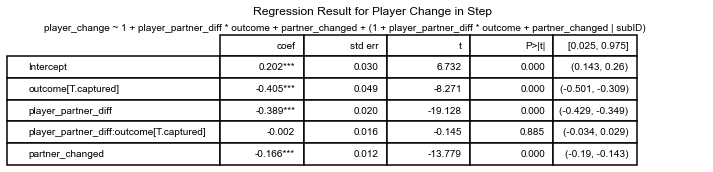

In [29]:
change_formula = 'player_change ~ 1 + player_partner_diff * outcome + partner_changed + (1 + player_partner_diff * outcome + partner_changed | subID)'
title = "Regression Result for Player Change in Step"
save_reg_to_table(change_model, 5, change_formula, title)

                                    Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 player_change
No. Observations:                   13533                   Method:                             ML           
No. Groups:                         250                     Scale:                              1.5645       
Min. group size:                    30                      Log-Likelihood:                     -23101.3775  
Max. group size:                    56                      Converged:                          Yes          
Mean group size:                    54.1                                                                     
-------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------

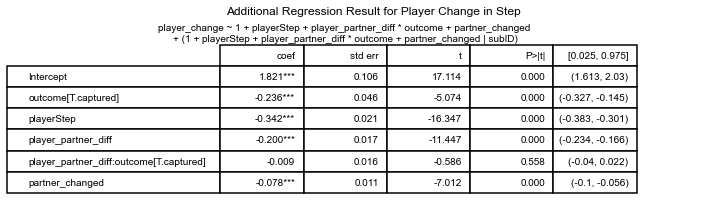

In [30]:
# additional regression controlling for player step
df_change_reg = df_cleaned.query('step_rt<8 and future_step_rt<8') #remove first and last trial and auto choices
# df_change_reg = pd.merge(df_change_reg, df_change_reg.groupby(['subID', 'predatorType'], as_index=False)['playerStep'].mean().rename({'playerStep':'avg_playerStep'}, axis=1))
# df_change_reg['mc_playerStep'] = df_change_reg['playerStep'] - df_change_reg['avg_playerStep']
df_change_reg = df_change_reg[['player_change', 'player_partner_diff', 'outcome', 'partner_changed', 'subID', 'trial', 'predatorType', 'playerStep', 'partnerStep']].dropna() #remove first and last trial
# df_change_reg['playerStep_centered'] = df_change_reg['playerStep'] - 5 #center this
change_model2 = smf.mixedlm('player_change ~ playerStep + player_partner_diff * outcome + partner_changed', 
                    data = df_change_reg,
                    groups = df_change_reg['subID'],
                    re_formula = '~ playerStep + player_partner_diff * outcome + partner_changed'
                ).fit(reml=False, method="lbfgs", maxiter=2000)
print(change_model2.summary())

change_formula = 'player_change ~ 1 + playerStep + player_partner_diff * outcome + partner_changed \n+ (1 + playerStep + player_partner_diff * outcome + partner_changed | subID)'
title = "Additional Regression Result for Player Change in Step\n"
save_reg_to_table(change_model2, 6, change_formula, title)

## reciprocity

TtestResult(statistic=2.0744714468741066, pvalue=0.03855177673224726, df=495.0)

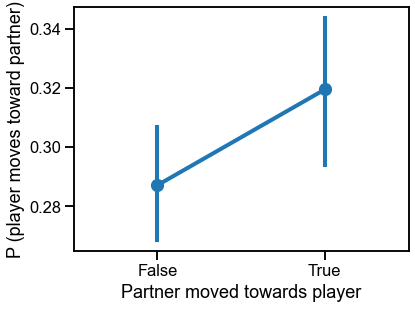

In [31]:
# test for reciprocity: if partner moves towards player on the previous round, will player move towards partner on the next round?
reciprocity = df_cleaned.copy()
# binarize
reciprocity['partner_changed'] = reciprocity['partner_changed_rel'] >0 
reciprocity['player_change'] = reciprocity['player_change_rel'] >0 

plt.figure(figsize=(6,4.5))
d = reciprocity.groupby(['subID', 'partner_changed'], as_index=False)['player_change'].mean()
sns.pointplot(data = d, x='partner_changed', y='player_change')
plt.ylabel('P (player moves toward partner)')
plt.xlabel('Partner moved towards player', labelpad=5)
ss.ttest_ind(d.query('partner_changed==True')['player_change'], d.query('partner_changed==False')['player_change'])

# Fig 4 Group dynamics clustering

In [32]:
##expand g so that grp_idv_step_diff is split into two columns based on order

#filter groups by riskiness
group_stat_filtered = filter_groups_by_riskiness(group_stat)
# group_stat_filtered['grp_idv_step_diff_risk_prone'] = None
# group_stat_filtered['grp_idv_step_diff_risk_averse'] = None

##take absolute of self_partner_risk_diff 
group_stat_filtered['idvDiff'] = np.abs(group_stat_filtered['self_partner_risk_diff'])

# Populate the columns based on the 'order' column
group_stat_filtered.loc[group_stat_filtered['risky_wpair'] == 'risk-prone', 'grp_idv_step_diff_risk_prone'] = group_stat_filtered['step_inc']
group_stat_filtered.loc[group_stat_filtered['risky_wpair'] == 'risk-averse', 'grp_idv_step_diff_risk_averse'] = group_stat_filtered['step_inc']

# Group by `sub` and `predatorType`, and aggregate
collapsed_g = group_stat_filtered.groupby(['room', 'predatorType']).agg({
    'individual': 'mean',  # or use 'mean'/'sum' if needed
    'idvDiff': 'first',  # or use 'mean'/'sum' if needed
    'reward': 'sum',  # or use 'mean'/'sum' if needed
    'jointMoney': 'mean',  # or use 'mean'/'sum' if needed
    'finalStep': 'first',  # or use 'mean'/'sum' if needed
    'group': 'first',  # or use 'mean'/'sum' if needed
    'grp_idv_step_diff_risk_prone': 'sum',  # Summing non-null values per group
    'grp_idv_step_diff_risk_averse': 'sum',  # Summing non-null values per group
    'predator': 'first'  # or use 'mean'/'sum' if needed
}).reset_index()

# Drop rows with NaN in both `grp_idv_step_diff_risk_prone` and `grp_idv_step_diff_risk_averse`
# collapsed_g.dropna(subset=['grp_idv_step_diff_risk_prone', 'grp_idv_step_diff_risk_averse'], how='all', inplace=True)

# Ensure that `grp_idv_step_diff_risk_prone` and `grp_idv_step_diff_risk_averse` columns are numeric
collapsed_g['grp_idv_step_diff_risk_prone'] = pd.to_numeric(collapsed_g['grp_idv_step_diff_risk_prone'], errors='coerce')
collapsed_g['grp_idv_step_diff_risk_averse'] = pd.to_numeric(collapsed_g['grp_idv_step_diff_risk_averse'], errors='coerce')

# Fill NaN values if needed (e.g., with 0 or another value)
# collapsed_g['grp_idv_step_diff_risk_prone'].fillna(0, inplace=True)
# collapsed_g['grp_idv_step_diff_risk_averse'].fillna(0, inplace=True)

## add a new column based on diff - low or high - based on median 

# Calculate the median of the 'diff' column
# median_diff = collapsed_g['idvDiff'].median()
# collapsed_g['diffCategory'] = np.where(collapsed_g['idvDiff'] > median_diff, 'high', 'low')

sns.set_context("talk")

keep 245 (room, predator)


cluster
risk converge    100
risk decrease     74
risk diverge      19
risk increase     52
Name: room, dtype: int64


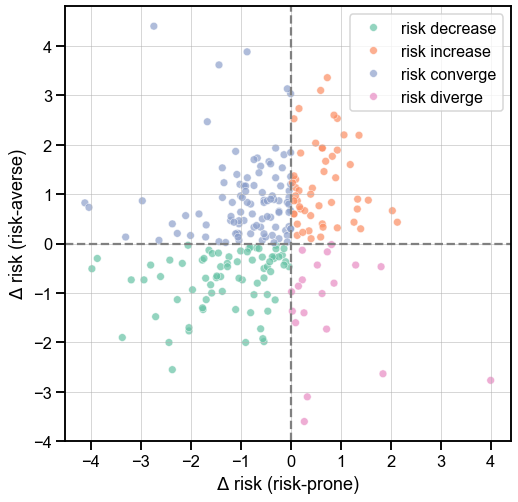

In [33]:
#manully separate them into 4 quadrants
def get_cluster(row):
    if row['grp_idv_step_diff_risk_prone'] >0:
        if row['grp_idv_step_diff_risk_averse'] >0:
            cluster = "risk increase"
        else:
            cluster = "risk diverge"
    else:
        if row['grp_idv_step_diff_risk_averse'] <0:
            cluster = "risk decrease"
        else:
            cluster = "risk converge"
    return cluster

collapsed_g['cluster'] = collapsed_g.apply(get_cluster, axis=1)
clusters = ['risk decrease', 'risk increase', 'risk converge', 'risk diverge']

# Scatter plot to show clusters
plt.figure(figsize=(8, 8))
sns.scatterplot(
    x='grp_idv_step_diff_risk_prone', 
    y='grp_idv_step_diff_risk_averse', 
    hue='cluster', 
    palette='Set2', 
    data=collapsed_g, 
    hue_order=clusters,
    s=60, 
    alpha=0.7
)

plt.axhline(0, color='gray', ls='--')
plt.axvline(0, color='gray', ls='--')
plt.xlabel('$\Delta$ risk (risk-prone)')
plt.ylabel('$\Delta$ risk (risk-averse)')
plt.legend(fontsize=16)
plt.grid(True, linewidth=0.5)

if save:
    plt.savefig(f'../paper_figs/{folder}/category_{folder}.png', 
            bbox_inches='tight', dpi=200)

print(collapsed_g.groupby('cluster')['room'].count())

## clustering differences

In [34]:
def mybar(**kwargs):
    sns.barplot(alpha=0.4, palette='Set2', order=clusters, **kwargs)

def myswarm(**kwargs):
    sns.swarmplot(palette='Set2', order=clusters, alpha=0.8, s=3, **kwargs)

                sum_sq     df         F    PR(>F)
C(cluster)   17.473807    3.0  4.228688  0.006163
Residual    331.953836  241.0       NaN       NaN
t = -3.4698850928904355, p = 0.0006159101486679407


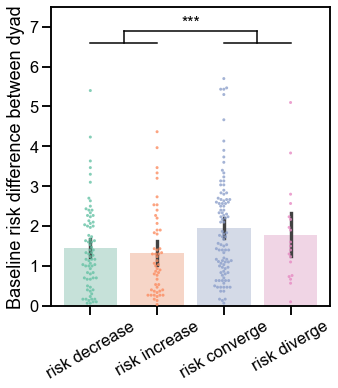

In [35]:
# Assume you already have 'collapsed_g' and 'clusters' defined
fig, ax = plt.subplots(1, 1, figsize=(5, 5.5))

# Plot swarm and barplot
myswarm(data=collapsed_g, x='cluster', y='idvDiff')
mybar(data=collapsed_g, x='cluster', y='idvDiff')

plt.xticks(rotation=30)
plt.ylabel('Baseline risk difference between dyad')
plt.xlabel('')
plt.ylim([0, 7.5])

# Run ANOVA
model = smf.ols('idvDiff ~ C(cluster)', data=collapsed_g).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# # --- Create combined groups ---
# # Define which clusters go into each combined group
group1_clusters = ['risk decrease', 'risk increase']  # <-- replace with your actual cluster labels
group2_clusters = ['risk converge', 'risk diverge']  # <-- replace with your actual cluster labels

# Create a temporary DataFrame with relabeled groups
collapsed_g_combined = collapsed_g.copy()
collapsed_g_combined['comparison_group'] = collapsed_g_combined['cluster'].apply(
    lambda x: 'Group1+2' if x in group1_clusters else ('Group3+4' if x in group2_clusters else 'Other')
)
t, p = ss.ttest_ind(collapsed_g_combined.query('comparison_group=="Group1+2"')['idvDiff'],
            collapsed_g_combined.query('comparison_group=="Group3+4"')['idvDiff'])
print(f"t = {t}, p = {p}")

y_h = 6.9
y_l = 6.6
# Annotate the plot
ax.text(x=1.5, y=y_h, s=get_sig(p),
        ha='center', va='bottom',
        fontsize=16, color='black')
ax.plot([0.5, 2.5], [y_h, y_h], color='black', linewidth=1.5)
ax.plot([0, 1], [y_l, y_l], color='black', linewidth=1.5)
ax.plot([2, 3], [y_l, y_l], color='black', linewidth=1.5)
ax.plot([0.5, 0.5], [y_l, y_h], color='black', linewidth=1.5)
ax.plot([2.5, 2.5], [y_l, y_h], color='black', linewidth=1.5)
if save:
    plt.savefig(f'../paper_figs/{folder}/risk_diff_by_category_{folder}.png', 
            bbox_inches='tight', dpi=200)

                sum_sq     df       F    PR(>F)
C(cluster)   41.206579    3.0  9.0095  0.000011
Residual    367.419045  241.0     NaN       NaN
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

risk decrease vs. risk increase: t-test independent samples, P_val:2.467e-05 t=4.383e+00
risk converge vs. risk diverge: t-test independent samples, P_val:1.104e-02 t=-2.583e+00


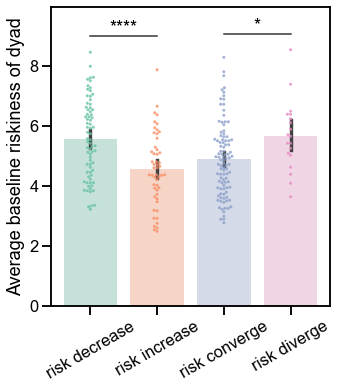

In [36]:

# sns.swarmplot(data = collapsed_g, x='cluster', y='idvDiff', palette='Set2', alpha=0.7)
fig, ax = plt.subplots(1, 1, figsize=(5, 5.5))
myswarm(data = collapsed_g, x='cluster', y='individual')
mybar(data = collapsed_g, x='cluster', y='individual')
plt.xticks(rotation=30)
plt.ylabel('Average baseline riskiness of dyad')
plt.xlabel('')
model = smf.ols('individual ~ C(cluster)', data=collapsed_g).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


#annotate?
pairs = [("risk increase", "risk decrease"), ("risk converge", "risk diverge"),]
annotator = Annotator(ax, pairs, data=collapsed_g, x='cluster', y='individual', 
                      order=clusters)
#set configurations and apply
annotator.configure(test='t-test_ind', hide_non_significant=True,
                    # comparisons_correction="bonferroni", 
                    text_format='star', loc='inside', 
                    line_height =0, text_offset=-1)#for style
annotator.apply_and_annotate()

if save:
    plt.savefig(f'../paper_figs/{folder}/avg_risk_by_category_{folder}.png', 
            bbox_inches='tight', dpi=200)

774
                            OLS Regression Results                            
Dep. Variable:               step_inc   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     36.88
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.37e-44
Time:                        21:17:16   Log-Likelihood:                -1148.8
No. Observations:                 774   AIC:                             2314.
Df Residuals:                     766   BIC:                             2351.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

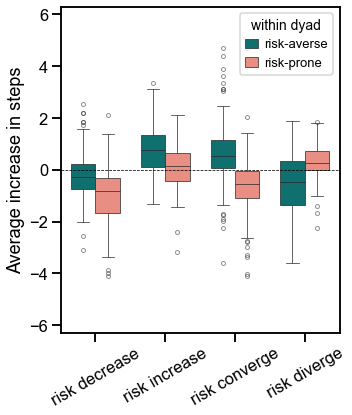

In [37]:
#further: who drives this increase or decrease?

plt.figure(figsize=(5, 6))
test = pd.merge(group_stat, collapsed_g[['room', 'cluster']].drop_duplicates())
print(len(test))
sns.boxplot(data = test, x='cluster', y='step_inc', palette=risk_colors, 
              hue='risky_wpair', order=clusters,
              width=0.7, linewidth=0.7, flierprops=dict(marker='o', markersize=4, alpha=0.5))
# sns.barplot(data = test, x='cluster', y='step_inc', palette='Set2', 
#               hue='risky_wpair', alpha=0.5)
plt.legend(title = 'within dyad', loc='upper right', 
           fontsize=13, title_fontsize=14, handletextpad=0.5,handlelength=1)
# sns.barplot(data = collapsed_g, x='cluster', y='idvDiff', palette='Set2', alpha=0.4)
plt.xticks(rotation=30)
plt.ylabel('Average increase in steps')
plt.axhline(0, color='black', ls='--', lw=0.75)
plt.xlabel('')
plt.ylim([-6.3, 6.3])
if save:
    plt.savefig(f'../paper_figs/{folder}/step_increase_by_category_{folder}.png', 
            bbox_inches='tight', dpi=200)
# model = smf.ols('idvDiff ~ C(cluster) + C(risky_wpair)', data=collapsed_g).fit()
# anova_table = sm.stats.anova_lm(model, typ=2)
# print(anova_table)

model = smf.ols('step_inc ~ C(cluster) * C(risky_wpair)', data=test).fit()
print(model.summary())

Cluster risk converge: t-statistic = 4.0832727097989725, p-value = 9.014861435524565e-05
Cluster risk decrease: t-statistic = -0.9456782741399503, p-value = 0.3474324486491447
Cluster risk diverge: t-statistic = -0.6335710630288718, p-value = 0.5343292950159371
Cluster risk increase: t-statistic = 7.528410410687753, p-value = 7.983574158516697e-10


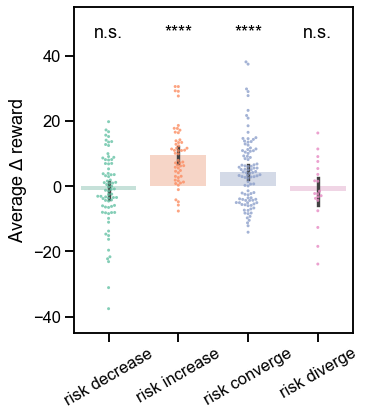

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(5, 6))
collapsed_g['grpIdvRewardDiff']= collapsed_g['jointMoney'] - collapsed_g['reward']
mybar(data = collapsed_g, x='cluster', y='grpIdvRewardDiff')
myswarm(data = collapsed_g, x='cluster', y='grpIdvRewardDiff')
# sns.boxplot(data = collapsed_g, x='cluster', y='grpIdvRewardDiff', palette='Set2')
plt.ylabel('Average $\Delta$ reward')
plt.xticks(rotation=30)
plt.ylim([-45, 55])
plt.xlabel('')


for i, subset in collapsed_g.groupby('cluster'):
    t, p = ss.ttest_1samp(subset['grpIdvRewardDiff'], 0)
    # Print the t-statistic and p-value
    print(f"Cluster {i}: t-statistic = {t}, p-value = {p}")
    #annotate
    idx = collapsed_g['cluster'].unique().tolist().index(i)
    #correct for multiple comparison
    ax.text(x=idx, y=47, s=get_sig(p),  ha='center', va='center')
    # ax.plot([idx-0.25, idx+0.25], [45, 45], color='black', linewidth=1.5)
if save:
    plt.savefig(f'../paper_figs/{folder}/reward_inc_by_category_{folder}.png', 
            bbox_inches='tight', dpi=200)

In [39]:
d = pd.merge(group_stat[['subID','room', 'predatorType', 'risky_wpair', 'reward_inc']], 
             collapsed_g[['room', 'predatorType', 'cluster']])
# ss.ttest_ind(d.query('cluster=="risk converge" and risky_wpair=="risk-averse"')['reward_inc'],
#              d.query('cluster=="risk increase" and risky_wpair=="risk-averse"')['reward_inc'])

# ss.ttest_ind(d.query('cluster=="risk converge" and risky_wpair=="risk-prone"')['reward_inc'],
#              d.query('cluster=="risk increase" and risky_wpair=="risk-prone"')['reward_inc'])

In [40]:
# can you just regress risk increase on 

In [41]:
# fig, ax = plt.subplots(1, 1, figsize=(5, 5.5))
# sns.barplot(data = collapsed_g, x='cluster', y='jointMoney', 
#             palette='Set2', alpha=0.4, order=clusters)
# sns.swarmplot(data = collapsed_g, x='cluster', y='jointMoney', 
#               palette='Set2', alpha=0.6, order=clusters)
# # sns.boxplot(data = collapsed_g, x='cluster', y='grpIdvRewardDiff', palette='Set2')
# plt.ylabel('dyad reward')
# plt.xticks(rotation=30)
# # plt.ylim([-42, 42])


# #annotate?
# annotator = Annotator(ax, pairs, data=collapsed_g, x='cluster', y='individual', 
#                       order=clusters)
# #set configurations and apply
# annotator.configure(test='t-test_ind', hide_non_significant=True,
#                     comparisons_correction="bonferroni", 
#                     text_format='star', loc='inside', 
#                     line_height =0, text_offset=-1)#for style
# annotator.apply_and_annotate()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

risk converge vs. risk diverge: t-test independent samples, P_val:1.104e-02 t=-2.583e+00
risk increase vs. risk diverge: t-test independent samples, P_val:7.773e-04 t=-3.517e+00
risk decrease vs. risk diverge: t-test independent samples, P_val:7.246e-01 t=-3.533e-01


(<Axes: ylabel='Average blame asynchrony'>,
  <statannotations.Annotation.Annotation at 0x7fe7f1c846a0>])

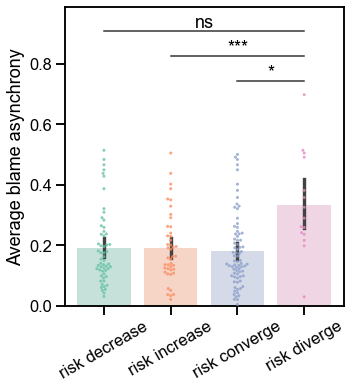

In [42]:
#no difference in sum blame. what about blame async?
fig, ax = plt.subplots(1, 1, figsize=(5, 5.5))
test= df_group.copy().query('selfBlame!=-1 and partnerBlame!=-1 and playerID==1') # keep 1 per group
test['blameAsync'] = abs(test['selfBlame'] + test['partnerBlame'] - 1)
test = test.groupby(['room'], as_index=False)['blameAsync'].mean()
collapsed_g2 = pd.merge(test,
                collapsed_g[['room', 'cluster']].drop_duplicates())


mybar(data = collapsed_g2, x='cluster', y='blameAsync')
myswarm(data = collapsed_g2, x='cluster', y='blameAsync')
plt.xticks(rotation=30)
plt.xlabel('')
plt.ylabel('Average blame asynchrony')

#annotate?
pairs = [("risk increase", "risk diverge"), 
         ("risk converge", "risk diverge"),
         ("risk decrease", "risk diverge"), 
        ]
annotator = Annotator(ax, pairs, data=collapsed_g, x='cluster', y='individual', 
                      order=clusters)
#set configurations and apply
annotator.configure(test='t-test_ind', hide_non_significant=False,
                    # comparisons_correction="bonferroni", 
                    text_format='star', loc='inside', 
                    line_height =0, text_offset=-1)#for style
annotator.apply_and_annotate()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

risk converge vs. risk diverge: t-test independent samples, P_val:4.833e-07 t=-5.177e+00
risk increase vs. risk diverge: t-test independent samples, P_val:5.944e-05 t=-4.141e+00
risk decrease vs. risk diverge: t-test independent samples, P_val:4.934e-05 t=-4.157e+00


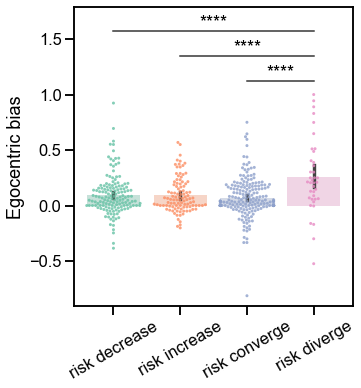

In [43]:
# self-attribution bias difference between clusters
bias_df = df_group.query('selfBlame!=-1').groupby(['attack', 'subID', 'room', 'predatorType'], as_index=False)['selfBlame'].mean()
bias_df = pd.merge(bias_df.query('attack==False'), bias_df.query('attack==True'), on=['subID', 'room', 'predatorType'])
bias_df['bias'] = bias_df['selfBlame_x'] - bias_df['selfBlame_y']
bias_df = pd.merge(bias_df[['subID', 'bias', 'room', 'predatorType']], collapsed_g)
# bias_df = bias_df.groupby(['room', 'cluster', 'predatorType'], as_index=False).mean()


fig, ax = plt.subplots(1, 1, figsize=(5, 5.5))
mybar(data = bias_df, x='cluster', y='bias')
myswarm(data = bias_df, x='cluster', y='bias')
# sns.stripplot(data = bias_df, x='cluster', y='bias', palette='Set2')
plt.xticks(rotation=30)
plt.xlabel('')
plt.ylabel('Egocentric bias')

#annotate?
pairs = [("risk increase", "risk diverge"), 
         ("risk converge", "risk diverge"),
         ("risk decrease", "risk diverge"), 
        #  ("risk increase", "risk converge"), 
        #  ("risk decrease", "risk converge"), 
        ]
annotator = Annotator(ax, pairs, data=bias_df, x='cluster', y='bias', 
                      order=clusters)
#set configurations and apply
annotator.configure(test='t-test_ind', hide_non_significant=False,
                    # comparisons_correction="bonferroni", 
                    text_format='star', loc='inside', 
                    line_height =0, text_offset=-1)#for style
annotator.apply_and_annotate()

if save:
    plt.savefig(f'../paper_figs/{folder}/blame_bias_by_category_{folder}.png', 
            bbox_inches='tight', dpi=200)

In [44]:
# #idv
# df_idv['player_change'] = df_idv.query('trial>60').groupby(['sub', 'predatorType'])['choice'].shift(-1) -df_idv['choice']
# # sns.lmplot(data=df_cleaned, x='partner_changed_rel', y='player_future_change_rel', scatter=False)
# sns.lineplot(data=df_idv.groupby(['sub', 'choice', 'predatorType'], as_index=False)['player_change'].mean(), 
#              x='choice', y='player_change', hue='predatorType')
# plt.ylim([-6, 6])
# # plt.xlabel('player partner step difference')
# # plt.ylabel('player step change')

In [45]:
#what drives this correlation?
# 

# Fig2 Sharing Responsibility

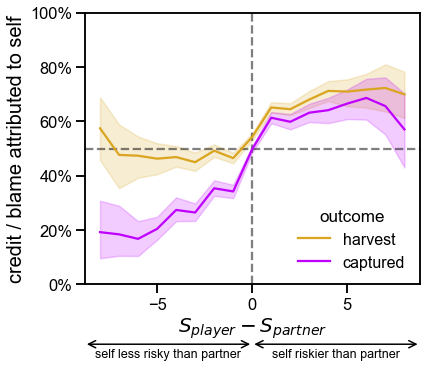

In [46]:
#plot split by step
plt.figure(figsize=(6, 5))
plt.axhline(y=0.5, ls='--', color='black', alpha=0.5)
plt.axvline(x=0, ls='--', color='black', alpha=0.5)
d = df_group.query('selfBlame!=-1').groupby(['subID','player_partner_diff', 'outcome'],
                                             as_index=False)['selfBlame'].mean()

d = d.query('player_partner_diff>-9 and player_partner_diff<9')
#for plotting
# d['outcome'] = d['attack'].apply(lambda x: 'win' if x==False else 'lose')
sns.lineplot(data=d, x='player_partner_diff', y='selfBlame', hue='outcome', 
            #  palette=['green', 'red'] #'fuchsia'
            palette = outcome_colors
            )
plt.xlabel('$S_{player} - S_{partner}$',fontsize=20)
plt.ylabel('credit / blame attributed to self', fontsize=20)
plt.ylim([0, 1])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0%', '20%', '40%', '60%', '80%', '100%'])
#plt.legend().remove()
plt.legend(loc='lower right',
           title='outcome', frameon=False,fontsize=16, title_fontsize=17)

# add arrows below
plt.annotate('', xy=(0, -0.22), xytext=(0.5, -0.22), 
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.annotate('', xy=(0.5, -0.22), xytext=(1, -0.22), 
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.annotate('self less risky than partner', xy=(0.03, -0.27), 
             xycoords='axes fraction', ha='left', fontsize=12.5)
plt.annotate('self riskier than partner', xy=(0.56, -0.27), 
             xycoords='axes fraction', ha='left', fontsize=12.5)
if save:
    plt.savefig(f'../paper_figs/{folder}/blame_{folder}.png', 
            bbox_inches='tight', dpi=200)

In [47]:
#for each subject, compare blame vs credit when self behind?

In [48]:
reg_data = df_group.query('selfBlame!=-1')
reg_data = reg_data[['subID', 'player_partner_diff', 'outcome', 'selfBlame', 'trial', 'predatorType']].dropna()
# mean center blame
reg_data['selfBlame'] = reg_data['selfBlame'] - 0.5
blame_model = smf.mixedlm(formula='selfBlame ~ player_partner_diff * outcome', 
                    data=reg_data, groups = reg_data['subID'],
                    re_formula="~ player_partner_diff * outcome"
                    ).fit()

print(blame_model.summary())
with open(f'../model_fits/regs/blame_reg_summary_{folder}.txt', "w") as f:
    f.write(blame_model.summary().as_text())

                                   Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  selfBlame
No. Observations:                    14544                    Method:                              REML     
No. Groups:                          250                      Scale:                               0.0226   
Min. group size:                     37                       Log-Likelihood:                      5857.7531
Max. group size:                     60                       Converged:                           Yes      
Mean group size:                     58.2                                                                   
------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------

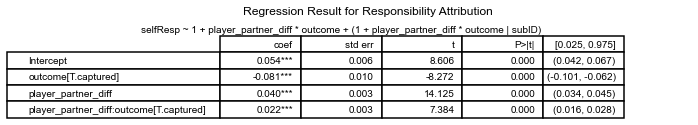

In [49]:
blame_formula = 'selfResp ~ 1 + player_partner_diff * outcome + (1 + player_partner_diff * outcome | subID)'
title = "Regression Result for Responsibility Attribution"
save_reg_to_table(blame_model, 4, blame_formula, title)

                                           Mixed Linear Model Regression Results
Model:                                    MixedLM                       Dependent Variable:                       selfBlame
No. Observations:                         14055                         Method:                                   REML     
No. Groups:                               250                           Scale:                                    0.0217   
Min. group size:                          10                            Log-Likelihood:                           5796.9766
Max. group size:                          60                            Converged:                                Yes      
Mean group size:                          56.2                                                                             
---------------------------------------------------------------------------------------------------------------------------
                                                   

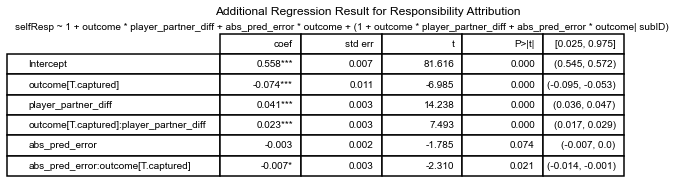

In [50]:
reg_data = df_group.query('selfBlame!=-1 and prediction>0')  # only include those who have selfBlame ratings

m_blame = smf.mixedlm(
    # "player_future_change ~ attack * selfBlame + player_partner_diff * selfBlame + attack * player_partner_diff",
    # "player_future_change ~ selfBlame * attack * player_partner_diff",
    "selfBlame ~ outcome * player_partner_diff + abs_pred_error * outcome",  # main effects + all interactions
    data=reg_data, 
    groups = reg_data['subID'],
    # re_formula="~attack + player_partner_diff + selfBlame",  # only random intercept here
    # re_formula="~attack * selfBlame + player_partner_diff * selfBlame + attack * player_partner_diff",  # random intercept + random slopes for attack and player_partner_diff
    re_formula="~outcome * player_partner_diff + abs_pred_error * outcome"
).fit(maxiter=5000, method='lbfgs')
print(m_blame.summary())

#save 
mb_formula = 'selfResp ~ 1 + outcome * player_partner_diff + abs_pred_error * outcome + (1 + outcome * player_partner_diff + abs_pred_error * outcome| subID)'
title = "Additional Regression Result for Responsibility Attribution"
save_reg_to_table(m_blame, 6, mb_formula, title, folder)

blame difference: r=3.507409636881551, p=0.0005370389480389595
blame asynchrony: r=-1.2238383409884022, p=0.22217465722484386


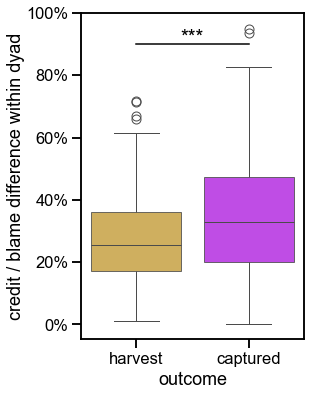

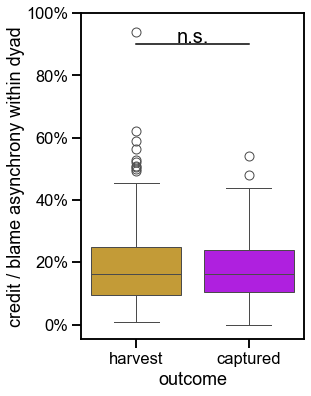

In [51]:
#bar plot of blame diff of each individual?
plt.figure(figsize=(4, 6))
df_group['blame_diff'] = df_group.groupby(['room', 'trial', 'predatorType'], as_index=False)['selfBlame'].diff()
df_group['blame_diff'] = np.abs(df_group['blame_diff'])
d = df_group.groupby(['outcome', 'room'], as_index=False)['blame_diff'].mean()
#more disagreement when attack happens. why?
sns.boxplot(data = d, x='outcome', y='blame_diff', palette=outcome_colors, 
            boxprops=dict(alpha=.8))
# plt.xticks([0, 1], ['win', 'lose'])
plt.ylim(top=1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0%', '20%', '40%', '60%', '80%', '100%'])
# plt.xlabel('outcome')
plt.ylabel('credit / blame difference within dyad', labelpad=1)
# run a independent t-test
r, p = ss.ttest_ind(d.query('outcome=="captured"')['blame_diff'], 
                    d.query('outcome=="harvest"')['blame_diff'])
print(f"blame difference: r={r}, p={p}")
#people are more likely to share reward than losses
sig = get_sig(p)
plt.text(0.5, 0.89, sig, ha='center', va='bottom', fontsize=20)
plt.plot([0, 0, 1, 1], [0.9, 0.9, 0.9, 0.9], lw=1.5, color='black')
if save:
    plt.savefig(f'../paper_figs/{folder}/blame_diff_{folder}.png', 
            bbox_inches='tight', dpi=200)


#bar plot of blame async of each dyad?
plt.figure(figsize=(4, 6))
test= df_group.copy()
test = test.dropna(subset=['partnerBlame']).query(
    'selfBlame!=-1 and partnerBlame!=-1')
test['blameAsync'] = abs(test['selfBlame'] + test['partnerBlame'] - 1)
d = test.query('playerID==0').groupby(['room', 'outcome'], as_index=False)['blameAsync'].mean()
#more disagreement when attack happens. why?
sns.boxplot(data = d, x='outcome', y='blameAsync', palette = outcome_colors)
# plt.xticks([0, 1], ['win', 'lose'])
plt.ylim(top=1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0%', '20%', '40%', '60%', '80%', '100%'])
# plt.xlabel('outcome')
plt.ylabel('credit / blame asynchrony within dyad', labelpad=1)
#run a paired t-test
r, p = ss.ttest_ind(d.query('outcome=="captured"')['blameAsync'], 
                    d.query('outcome=="harvest"')['blameAsync'])
print(f"blame asynchrony: r={r}, p={p}")
#people are more likely to share reward than losses
#people are more likely to share reward than losses
# Annotate the plot with significance if p-value < 0.05
sig = get_sig(p)
plt.text(0.5, 0.89, sig, ha='center', va='bottom', fontsize=20)
plt.plot([0, 0, 1, 1], [0.9, 0.9, 0.9, 0.9], lw=1.5, color='black')

### compromise ~ blame

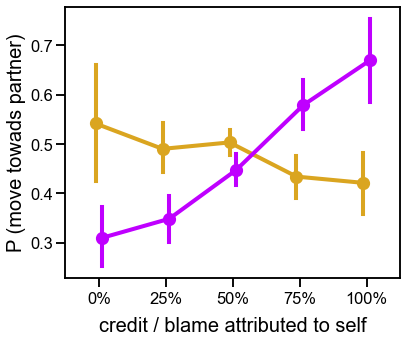

In [52]:
#plot step change vs blame, separate by attack
plt.figure(figsize=(6, 5))
df_group['future_step_change'] = df_group.groupby(['subID', 'predatorType'])['playerStep'].shift(-1) - df_group['playerStep']
df_group['future_step_rt'] = df_group.groupby(['subID', 'predatorType'])['step_rt'].shift(-1)
test = df_group.query('selfBlame!=-1').copy()
#test['player_partner_diff'] =  np.sign(test['player_partner_diff'])  # Convert to binary
# test['selfBlame'] = np.sign(test['selfBlame'] - 0.5)  # Convert blame to -1, 0, 1
test['compromise'] =  np.sign(test['future_step_change']) == -np.sign(test['player_partner_diff'])  # Convert to binary
# test['compromise'] =  - test['future_step_change'] / test['player_partner_diff']
test['outcome'] = test['attack'].apply(lambda x: 'win' if x==False else 'lose')
d=test.groupby(['subID', 'selfBlame', 'outcome'], as_index=False)['compromise'].mean()
sns.pointplot(data = d, hue='outcome', y='compromise', x='selfBlame', palette=outcome_palette, dodge=0.1)
# plt.legend(loc='upper center', title='outcome')
plt.legend().remove()
# plt.legend().remove()
plt.ylabel('P (move towads partner)', fontsize=20)
# plt.ylim([0, 1])
plt.xlabel('credit / blame attributed to self', labelpad=10, fontsize=20)
# plt.xticks([0, 0.25, 0.5, 0.75, 1], ['0%', '25%', '50%', '75%', '100%'])
plt.xticks([0, 1, 2, 3, 4], ['0%', '25%', '50%', '75%', '100%'])
if save:
    plt.savefig(f'../paper_figs/{folder}/compromise_blame_{folder}.png',
                bbox_inches='tight', dpi=200)



# Fig3 comp model

In [53]:
m1_list = [
        # "peppgFull_econ_Theta_mse", 
        "realPrediction_lrdecay_peppgFull_econ_ThetaGamma", 
        # "valueppgFull_econ_Theta_mse", 
        # "valueppgFull_econ_ThetaGamma_mse"
        ]
m2_list = ["arbWeight_llh", "updateTheta_llh", "asIfIdv_llh"] #"deltaWeight",

## model comparison

In [54]:
def read_model_df(mname, fname, folder = folder):
    if fname != '':
        fname = '_' + fname
    if folder == "conf":
        rep2 = pd.read_csv(f'../model_fits/rl_rep2/{mname}{fname}.csv')
        rep2['subID']= rep2['subID'] + 400

        df = pd.concat([rep2, pd.read_csv(f"../model_fits/rl_conf/{mname}{fname}.csv")])
    else:
        df = pd.read_csv(f"../model_fits/rl_expl/{mname}{fname}.csv")
        
    return df

In [55]:
def read_simulations(mname, sim_type='full', agg_type = 'mean', folder=folder):
    sim_df_grp = read_model_df(mname, f'sim_group_{sim_type}')
    sim_df_idv = read_model_df(mname, f'sim_idv_{sim_type}')
    if agg_type == 'mean':
        sim_df_grp['sim_playerStep'] = sim_df_grp['sim_playerStep'].apply(lambda x: np.mean(eval(x)))
        sim_df_idv['sim_choice'] = sim_df_idv['sim_choice'].apply(lambda x: np.mean(eval(x)))
    elif agg_type == 'first':
        sim_df_grp['sim_playerStep'] = sim_df_grp['sim_playerStep'].apply(lambda x: eval(x)[1])
        sim_df_idv['sim_choice'] = sim_df_idv['sim_choice'].apply(lambda x: eval(x)[1])
    elif agg_type == 'mode':
        sim_df_grp['sim_playerStep'] = sim_df_grp['sim_playerStep'].apply(lambda x: ss.mode(eval(x))[0])
        sim_df_idv['sim_choice'] = sim_df_idv['sim_choice'].apply(lambda x: ss.mode(eval(x))[0])


    assert min(sim_df_grp['subID'])==0
    sim_df_grp = pd.merge(sim_df_grp, df_group).sort_values(by=['subID', 'trial']).reset_index(drop=True)
    # sim_g = sim_df_grp.groupby(['subID', 'predatorType'], as_index=False)[['playerStep', 'sim_playerStep']].mean() 

    sim_df_idv = pd.merge(sim_df_idv, df_idv).sort_values(by=['subID', 'trial']).reset_index(drop=True)
    # sim_i = sim_df_idv.groupby(['subID', 'predatorType'], as_index=False)[['choice', 'sim_choice']].mean()

    return sim_df_grp, sim_df_idv

In [56]:
# add BIC and AIC for model comparison
def mybic(nll, k, N): #176 trials becuase we ignored the first trial for each predator
    return k * np.log(N) + 2 * nll

def myaic(nll, k, N):
    return k * 2 +2 * nll

### BIC

In [57]:
all_params_df = pd.DataFrame()

for mymodel in m1_list:
    for mymodel2 in m2_list:
        # try:
        params_df = read_model_df(f"{mymodel}_{mymodel2}", '')
        params_df['model_name'] = mymodel2
        k = 4 if "asIfIdv" not in mymodel2 else 3
        num_trials = df_group.query('step_rt<8').groupby('subID', as_index=False)['trial'].count()
        params_df = pd.merge(params_df, num_trials)
        if 'nll' not in params_df.columns:
            params_df['nll'] = params_df['nll_idv'] + params_df['nll_grp']
        params_df['bic'] = params_df.apply(lambda row: mybic(row['nll'], k, 118+row['trial']), axis=1)
        params_df['aic'] = params_df.apply(lambda row: myaic(row['nll'], k, 118+row['trial']), axis=1)
        all_params_df = pd.concat([all_params_df, params_df])
        # except:
        #     pass

print(all_params_df['model_name'].unique())
print(len(all_params_df['subID'].unique()))
# if min(all_params_df['subID'])==1:
#     all_params_df['subID'] = all_params_df['subID'] - 1
# print(f"{len(params_df.subID.unique())} subs with avg nll = {np.mean(params_df.loc[params_df.nll!=np.inf]['nll'])}")
all_params_df.head()




['arbWeight_llh' 'updateTheta_llh' 'asIfIdv_llh']
250


,subID,alpha,theta,gamma,w,nll_idv,nll_grp,model_name,trial,nll,bic,aic
0,18,0.59,0.93,0.28,0.50,320.495187,116.929036,arbWeight_llh,59,437.424224,895.553046,882.848447
1,14,0.68,0.64,0.62,0.33,213.898199,135.312346,arbWeight_llh,60,349.210545,719.148225,706.421091
2,4,0.79,0.51,0.68,0.48,171.049067,118.057613,arbWeight_llh,59,289.106680,598.917959,586.213360
3,0,1.00,0.68,0.80,0.66,181.312500,59.692244,arbWeight_llh,60,241.004744,502.736623,490.009489
4,2,1.00,0.88,0.84,0.68,206.745001,69.087576,arbWeight_llh,60,275.832577,572.392288,559.665154


In [58]:
df_idv.columns

Index(['Unnamed: 0', 'attack', 'attackProb', 'attackRange', 'choice', 'color',
       'currProb', 'predatorType', 'reward', 'round', 'rt', 'totMoney', 'sub',
       'trial', 'sub_full', 'subID', 'remap_subID', 'predator',
       'num_encounter'],
      dtype='object')

In [59]:
#make sure the order matches!
model_names = ['Other-regarding\npreference\n', 'Social\ninfluence', 'As-if\nindividual']

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

arbWeight_llh vs. updateTheta_llh: Wilcoxon test (paired samples), P_val:2.153e-20 Stat=5.034e+03
arbWeight_llh vs. asIfIdv_llh: Wilcoxon test (paired samples), P_val:6.401e-32 Stat=2.230e+03


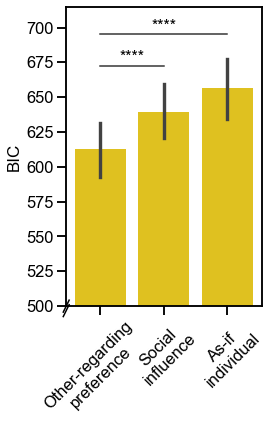

In [60]:
sns.set_context("talk")
fig, ax = plt.subplots(1, 1, figsize=(3.5, 5.5))
sns.barplot(data = all_params_df, x='model_name', y='bic', color='gold',
            # errorbar="se", 
            # s=3, alpha=0.8, 
            order = m2_list)
# sns.boxplot(data = all_params_df, x='model_name', y='bic', showfliers=False)
#set xticks
plt.xticks(np.arange(len(model_names)), model_names, rotation=45)
plt.xlabel('')
plt.ylabel('BIC', fontsize=17)
plt.ylim(bottom=500)

# calculate delta_BIC
baseline = m2_list[0]
df_delta = all_params_df.copy()
df_delta["delta_bic"] = df_delta["bic"] - df_delta.groupby("subID")["bic"].transform(
    lambda x: x.iloc[0] if x.index[0] in all_params_df[all_params_df["model_name"] == baseline].index else x
)

pairs = [(baseline, m) for m in m2_list if m != baseline]

annotator = Annotator(
    ax, pairs,
    data=df_delta,
    x='model_name',
    y='delta_bic',
    order=m2_list
)

annotator.configure(
    test='Wilcoxon',
    text_format='star',
    loc='inside',
    fontsize=16,
    line_height=0,
)

annotator.apply_and_annotate()

#add annotation
# pairs=[(0, 1), (0, 2), (1, 2)]
# pairs = [(m2_list[i], m2_list[j]) for i in range(len(m2_list)) for j in range(i)]
# # pairs = [(m2_list[0], m2_list[1]), (m2_list[0], m2_list[2])]
# annotator = Annotator(ax, pairs, data=all_params_df, x='model_name', y='bic', 
#                       order=m2_list)
# #set configurations and apply
# annotator.configure(test='Wilcoxon', text_format='star', loc='inside',
#                     line_height =0, text_offset=-1, hide_non_significant=False)#for style
# annotator.apply_and_annotate()

# plt.ylim([0, 200])
# plt.tight_layout()
if save:
    plt.savefig(f'../paper_figs/{folder}/bic_{folder}.png', 
                bbox_inches='tight', dpi=200)
    
# after plt.ylim(bottom=600)
kwargs = dict(transform=ax.transAxes, color='k', clip_on=False, linewidth=1.5)
ax.plot((-0.015, 0.015), (-0.02, 0.02), **kwargs)   # bottom-left slash
ax.plot((-0.015, 0.015), (-0.035, 0.005), **kwargs)  # double slash

In [61]:
best_models = pd.merge(all_params_df, all_params_df.groupby('subID', as_index=False)['bic'].min())
model_of_interest = "arbWeight_llh"
# model_of_interest = "asIfIdv_llh"
# model_of_interest = "updateTheta_llh"

total_subjects = len(all_params_df['subID'].unique())
proportion = len(best_models.query('model_name==@model_of_interest')) / total_subjects

print(f"Proportion of subjects fit best by {model_of_interest}: {proportion:.2f}")


Proportion of subjects fit best by arbWeight_llh: 0.69


### simulations

In [62]:
def count_freq(sc, rc, mytype):
    #sc in [trials * k]
    #rc in [trial, 1]
    freq = []
    for i, real_c in enumerate(rc):
        #maybe smooth this mse?
        if mytype=='l2' or mytype=='mse':
            freq.append(np.sum(np.abs(sc[i,:] - real_c) **2))
        elif mytype=='l1':
            freq.append(np.sum(np.abs(sc[i,:] - real_c)))

        # freq.append(np.sum(sc[i,:] == real_c))
    return np.mean(freq) / sc.shape[1]


def compare_sim(sim_df_grp, sim_df_idv, m2_list, mytype='l2', plot=False):
    # models = df.model_name.unique()
    # subs = set.intersection(*df.groupby('model_name')['subID'].apply(set).values)
    subs  = sim_df_grp['subID'].unique()
    mse = np.zeros([len(subs), 2, len(m2_list)]) #num_subs * num_predators * num_models
    
    for i, sub in enumerate(subs): #loop over each subject
        for pt in [0, 1]: #loop over each predator
            # try:
            dist = 0
            # subset_idv = df_idv.query('subID==@sub and predatorType==@pt and trial>60')
            # subset_grp = df_group.query('subID==@sub and predatorType==@pt')
            # sub_resp = subset_grp.query('step_rt<8 and playerStep>0')['trial'].values
            subset_sim_grp = sim_df_grp.query('subID==@sub and predatorType==@pt and step_rt<8 and playerStep>0')
            subset_sim_idv = sim_df_idv.query('subID==@sub and predatorType==@pt and trial>60')
            # print(f"{sub}number of responses: {len(sub_resp)} and {len(subset_sim_grp)}")
            
            for j, m in enumerate(m2_list): #loop over each model      
                model_sim_data = subset_sim_grp.query('model_name==@m')
                sc = model_sim_data['sim_playerStep'].values
                try:
                    sc = [np.mean(i) for i in sc]
                except:
                    pass
                # print(sc)
                rc = model_sim_data['playerStep'].values
                # sc = np.reshape(sc, [len(rc), -1])
                # print(sc.shape)
                #ignore auto response
                # sc = sc[sub_resp - 1, :]
                # rc = rc[sub_resp - 1]
                # feq = count_freq(sc, rc, mytype)
                if mytype=='l2' or mytype=='mse':
                    feq = np.mean((sc - rc) ** 2)
                elif mytype=='l1':
                    feq = np.mean(np.abs(sc - rc))

                # sc = subset_sim_idv.query('model_name==@m')['sim_choice'].values
                # rc = subset_idv['choice'].values
                # dist2, ylab = get_dist(sc, rc, mytype)
                mse[i, pt, j] = feq
            # except:
            #     print(sub)
        
    #flatten with the predator dimension
    mse = np.nanmean(mse, axis=1) # shape: [sub, model]
    

    return mse

In [63]:
# what's the baseline MSE if we just predict the mean choice of each subject for each predator?
new = pd.merge(
    df_idv.query('trial>60').groupby(['subID', 'predatorType'], as_index=False)['choice'].mean(),
        #   .agg(lambda x: list(x.mode())[0]),
    df_group[['playerStep', 'subID', 'predatorType', 'trial']],
    on=['subID', 'predatorType']
)
baseline_mse = new.groupby(['subID']).apply(lambda x: np.square(x['choice'] - x['playerStep']).median())
# plt.boxplot(baseline_mse, showfliers=False)
print(f"Baseline MSE: {baseline_mse.median():.2f} ± {baseline_mse.sem():.2f}")

Baseline MSE: 1.07 ± 0.19


In [64]:
model_names_org = [f"{mymodel}_arbWeight_llh", f"{mymodel}_updateTheta_llh", f"{mymodel}_asIfIdv_llh"]
sim_type="full"

all_preds_grp = pd.DataFrame()
all_preds_idv = pd.DataFrame()
for mname in model_names_org:
    print(mname)
    # sim_g = read_model_df(mname, f'sim_group_{sim_type}')
    sim_g, sim_i = read_simulations(mname, sim_type=sim_type, agg_type='mean')
    sim_g['model_name'] = mname.split("_")[-2]
    sim_i['model_name'] = mname.split("_")[-2]
    all_preds_grp = pd.concat([all_preds_grp, sim_g]) 
    all_preds_idv = pd.concat([all_preds_idv, sim_i])

m2_list = all_preds_grp.model_name.unique()
print(m2_list)
dist = compare_sim(all_preds_grp, all_preds_idv, m2_list, plot=False, mytype='l2')

realPrediction_lrdecay_peppgFull_econ_ThetaGamma_arbWeight_llh
realPrediction_lrdecay_peppgFull_econ_ThetaGamma_updateTheta_llh
realPrediction_lrdecay_peppgFull_econ_ThetaGamma_asIfIdv_llh
['arbWeight' 'updateTheta' 'asIfIdv']


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test paired samples, P_val:3.275e-02 t=-2.147e+00
1 vs. 2: t-test paired samples, P_val:1.467e-10 t=-6.690e+00
0 vs. 2: t-test paired samples, P_val:1.174e-11 t=-7.117e+00


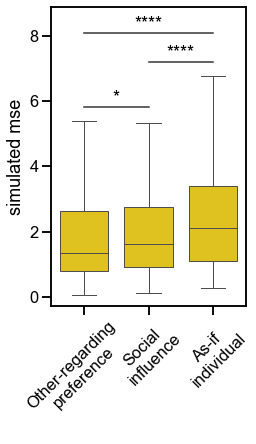

In [65]:
all_preds_grp = all_preds_grp.sort_values(by=['model_name', 'subID', 'predatorType', 'trial'])
# Convert the matrix into a DataFrame
df = pd.DataFrame(dist, columns=[i for i in range(dist.shape[1])])
# Melt the DataFrame to long format for seaborn compatibility
df_long = df.melt(var_name='X', value_name='Y')

# Create the swarm plot
fig, ax = plt.subplots(1, 1, figsize=(3.5, 5.5))
# sns.pointplot(x='X', y='Y', data=df_long, errorbar="se", color='gold')
sns.boxplot(x='X', y='Y', data=df_long, showfliers=False, color='gold', width=0.75)
# sns.violinplot(x='X', y='Y', data=df_long,color='gold')
#set x, y labels
plt.ylabel('simulated mse')
plt.xlabel('')
#rename models
plt.xticks(np.arange(len(model_names)), model_names, rotation=45)

#add annotation
pairs=[(0, 1), (0, 2), (1, 2)]
annotator = Annotator(ax, pairs, data=df_long, x='X', y='Y', order=[0, 1, 2])
#set configurations and apply
annotator.configure(test='t-test_paired', text_format='star', loc='inside',
                    line_height =0, text_offset=-0.1, hide_non_significant=False)#for style
annotator.apply_and_annotate()

# Add extra space at the top of the plot
# plt.ylim(1, 1.26) 

if save:
    plt.savefig(f'../paper_figs/{folder}/simulated_mse_{folder}.png', 
                bbox_inches='tight', dpi=200)



## read best-fitting model

In [66]:
mymodel = "realPrediction_lrdecay_peppgFull_econ_ThetaGamma"
mymodel2 = "arbWeight_llh"
mname = f"{mymodel}_{mymodel2}"

GENRULE, CHOICERULE = mymodel.split("_")[0:2]
print([GENRULE, CHOICERULE])

params_df = read_model_df(mname, '', folder)
if 'nll' not in params_df.columns:
    params_df['nll'] = params_df['nll_idv'] + params_df['nll_grp']
print(f"{len(params_df)} subjects with avg nll {np.mean(params_df['nll'])}")
params_df.head()

['realPrediction', 'lrdecay']
250 subjects with avg nll 295.8937320221484


,subID,alpha,theta,gamma,w,nll_idv,nll_grp,nll
0,18,0.59,0.93,0.28,0.50,320.495187,116.929036,437.424224
1,14,0.68,0.64,0.62,0.33,213.898199,135.312346,349.210545
2,4,0.79,0.51,0.68,0.48,171.049067,118.057613,289.106680
3,0,1.00,0.68,0.80,0.66,181.312500,59.692244,241.004744
4,2,1.00,0.88,0.84,0.68,206.745001,69.087576,275.832577


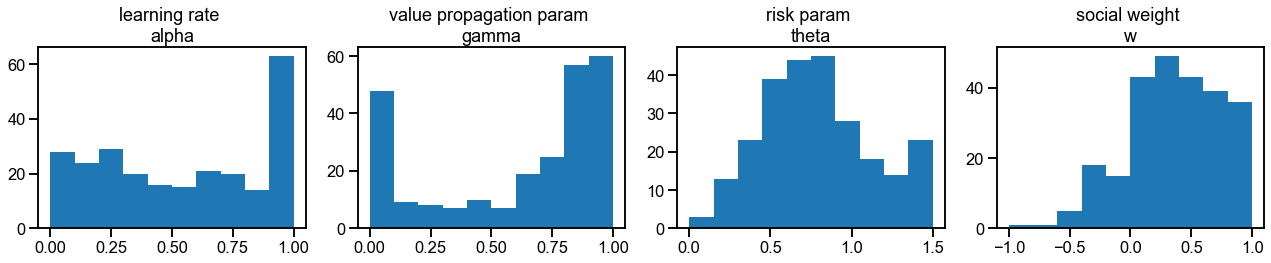

In [67]:
fig, axes = plt.subplots(1,4,figsize=(18,4))
axes[0].hist(params_df['alpha'])
axes[1].hist(params_df['gamma'])
axes[2].hist(params_df['theta'])
axes[3].hist(params_df['w'])
# axes[4].hist(params_df['delta'])
axes[0].set_title('learning rate \nalpha')
axes[1].set_title('value propagation param \ngamma')
axes[2].set_title('risk param \ntheta')
axes[3].set_title('social weight \nw')
plt.tight_layout()


          $\alpha$  $\gamma$  $\theta$     w
$\alpha$      1.00      0.38     -0.15  0.01
$\gamma$      0.38      1.00     -0.31 -0.14
$\theta$     -0.15     -0.31      1.00  0.07
w             0.01     -0.14      0.07  1.00


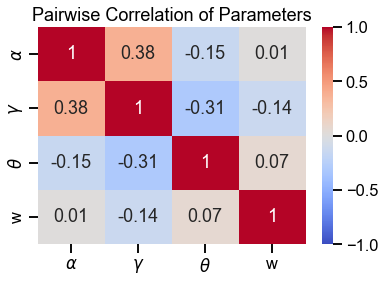

In [68]:
param_cols = ['alpha', 'gamma', 'theta', 'w']
params = params_df[param_cols]
params = params.rename({'alpha':r"$\alpha$", 
                        'gamma':r"$\gamma$",
                        'theta':r"$\theta$",
                        }, axis=1)

# Compute pairwise Pearson correlations
corr_matrix = params.corr(method='pearson')
corr_matrix = corr_matrix.round(2)
print(corr_matrix)

# Optional: visualize with seaborn heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Pairwise Correlation of Parameters")
plt.show()


# # Create pairwise scatterplots
# # Create a custom PairGrid to mask upper triangle
# g = sns.PairGrid(params, corner=True)  # corner=True shows only lower triangle

# # Add scatterplot and regression line to lower triangle
# g.map_lower(sns.regplot, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

# # Optional: add histograms on diagonal
# g.map_diag(sns.histplot, kde=True)

          25%  50% (Median)     75%
alpha  0.2500         0.560  0.8975
gamma  0.2825         0.775  0.8800
theta  0.5400         0.760  0.9875
w      0.1000         0.390  0.6675


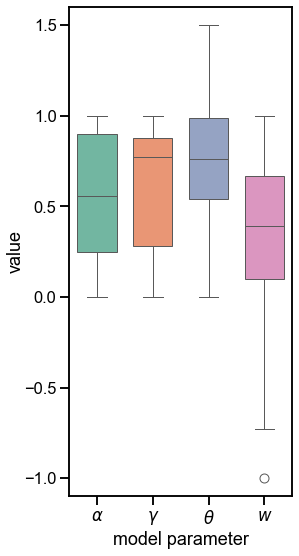

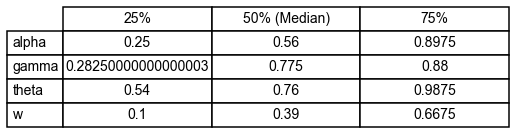

In [69]:
#box plot
plt.figure(figsize=(4, 9))
plt.ylim([-1.1, 1.6])
# t = params_df[['alpha_w', 'alpha_l', 'theta', 'w', 'subID']].melt(id_vars='subID')
t = params_df[['alpha', 'gamma', 'theta', 'w', 'subID']].melt(id_vars='subID')
sns.boxplot(data = t, x='variable', y='value', palette= sns.color_palette("Set2"), width=0.7)
plt.xticks(range(4), [r'$\alpha$', r'$\gamma$', r'$\theta$', r'$w$'])
plt.xlabel('model parameter')
plt.ylabel('value', labelpad=-1)

if save:
    plt.savefig(f'../paper_figs/{folder}/params_dist_{folder}.png', bbox_inches='tight', dpi=200)



# print summary statcistics
summary = params_df[['alpha', 'gamma', 'theta', 'w']].quantile([0.25, 0.5, 0.75]).T
summary.columns = ['25%', '50% (Median)', '75%']
# Step 2: Create table as plot
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')  # Hide axes

table = ax.table(
    cellText=summary.values,
    rowLabels=summary.index,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center'
)

table.scale(1, 2)  # Scale table cells
table.auto_set_font_size(False)
table.set_fontsize(14)
# save
if save:
    plt.savefig(f'../paper_figs/{folder}/params_summary_{folder}.png', bbox_inches='tight', dpi=200)
print(summary)


### parameter correlation with behavior

[250, -0.36322408682949336, 3.266004083511281e-09]
[250, 0.7764280626209519, 1.2153115201270389e-51]
[250, 0.24034584979058474, 0.00012426306729005268]


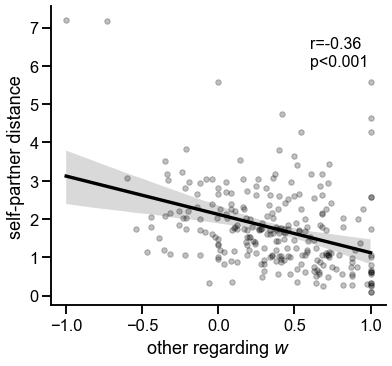

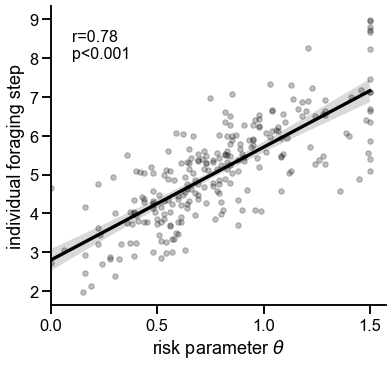

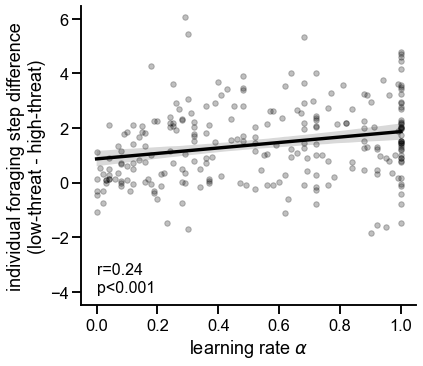

In [70]:
scatter_kws = {'alpha':0.25, 's':30, 'color':'black'}

def plot_param_correlation(d, xvar, yvar, xlabel, ylabel, xloc, yloc):
    d = pd.merge(params_df, d)

    plt.figure(figsize=(6, 5.5))
    sns.regplot(data=d, x=xvar, y=yvar, 
            scatter_kws = scatter_kws, line_kws={'color': 'black'},
            )
    r, p = ss.pearsonr(d[xvar], d[yvar])
    print([len(d), r, p])
    
    if p<0.001:
        p = '<0.001'
    else:
        p = f"={round(p, 3)}"
    if xvar =='theta':
        plt.xlim(left=xloc-0.1)
    if xvar=='alpha':
        plt.ylim(bottom=yloc-0.5)

    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    sns.despine()
    plt.text(
        xloc, yloc,
        f'r={r:.2f}\np{p}',
        fontsize=16
    )
    if save:
        plt.savefig(f'../paper_figs/{folder}/supp_correlation_{xvar}_{folder}.png', 
            bbox_inches='tight', dpi=200)


# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#is convergence correlated with w? larger weight on partner pref -> more convergence
d = df_group.groupby('subID', as_index=False
        )['player_partner_diff'].apply(lambda x: np.mean(np.absolute(x)))
plot_param_correlation(d, 'w', 'player_partner_diff', 'other regarding $w$', 'self-partner distance', 0.6, 6)

#higher prelec param -> underweighting of small probability -> risk-averse
#higher econ risk param ->risky
d = df_idv.query('trial>60').groupby(['subID'], as_index=False)['choice'].mean()
plot_param_correlation(d, 'theta', 'choice', 'risk parameter ' + r'$\theta$', 'individual foraging step', 0.1, 8)


#can different model predict different choice patterns towards different predators?
d = df_idv.query('trial>60').groupby(['subID', 'predatorType'], as_index=False)['choice'].mean()
d = pd.merge(d.query('predatorType==0'), d.query('predatorType==1'), on='subID')
d['choice_diff'] = d['choice_x'] - d['choice_y']
#correlate learning rates with differences in choice between predators
# sns.set_context('talk')
plot_param_correlation(d, 'alpha', 'choice_diff', 'learning rate '+r'$\alpha$', 'individual foraging step difference\n(low-threat - high-threat)', 0, -4)




### model fit and parameter recovery

realPrediction_lrdecay_peppgFull_econ_ThetaGamma_arbWeight_llh
250


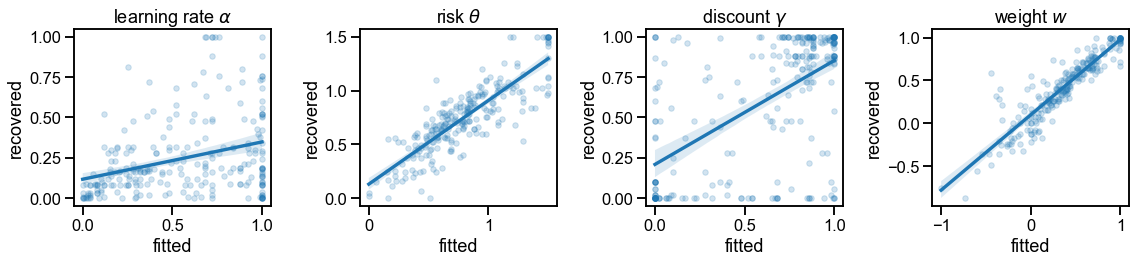

In [71]:
#show recovery
# mymodel = "peppgFull_econ_ThetaGamma"
# mymodel2 = "arbWeight"

print(mname)

rec_df = read_model_df(mname, 'recovery')
m = pd.merge(params_df, rec_df, on=['subID'])
# # #if fit by sub:
# rec_df['subID'] = rec_df['subID']-1
# rec_df.head()
m.head()

sns.set_context('talk')
m['gamma2_x'] = m['gamma_x'] * m['alpha_x']
m['gamma2_y'] = m['gamma_y'] * m['alpha_y']
print(len(m))
col_names = {'alpha':r'learning rate $\alpha$',
             'theta': r'risk $\theta$',
             'gamma': r'discount $\gamma$',
             'w':r'weight $w$'}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(['alpha', 'theta', 'gamma', 'w']):
    sns.regplot(data=m, x=col+'_x', y=col+'_y', ax=axes[i], scatter_kws={'s':30, 'alpha':0.2})
    # axes[i].plot([axes[i].get_xlim()[0], axes[i].get_xlim()[1]], [axes[i].get_ylim()[0], axes[i].get_ylim()[1]], 
    #              ls='--', lw=1.5)
    #add title
    # col = re.sub(r'\d+', '', col)
    # axes[i].set_title(f"$\{col}$" if col!='w' else f"${col}$")
    axes[i].set_title(col_names[col])
    axes[i].set_xlabel('fitted')
    axes[i].set_ylabel('recovered')
    ss.pearsonr(m['w_x'], m['w_y'])

    
plt.tight_layout()
if save:
    plt.savefig(f'../paper_figs/{folder}/supp_recovery_{mymodel}_{mymodel2}_{folder}.png', 
                bbox_inches='tight', dpi=200)

In [72]:
sim_g, sim_i = read_simulations(mname, sim_type='full', agg_type='first')

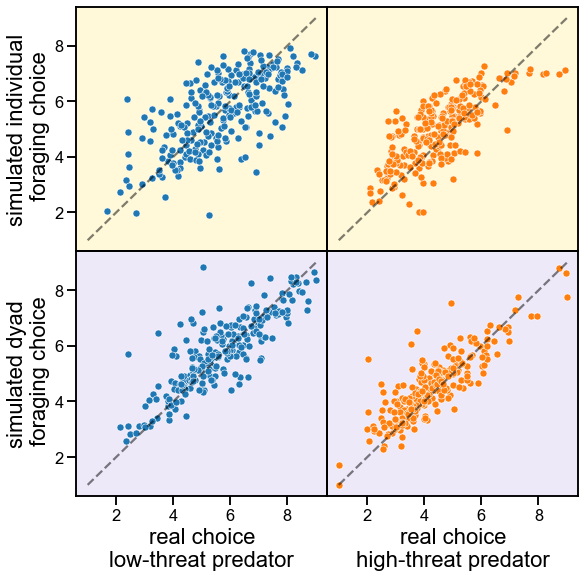

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9), sharex=True, sharey=True)
colors=sns.color_palette()
for i in [0, 1]: #fore each predator
    axes[0, i].plot([1, 9], [1, 9], ls='--', color='black', alpha=0.5)
    axes[1, i].plot([1, 9], [1, 9], ls='--', color='black', alpha=0.5)
    #idv
    sim_i = sim_i.groupby(['subID', 'predatorType'], as_index=False)[['choice', 'sim_choice']].mean()
    sns.scatterplot(x=sim_i.query('predatorType==@i')['choice'], 
                    y=sim_i.query('predatorType==@i')['sim_choice'], 
                    ax=axes[0, i], color=colors[i], s=50)
    #group
    sim_g = sim_g.groupby(['subID', 'predatorType'], as_index=False)[['playerStep', 'sim_playerStep']].mean()
    sns.scatterplot(x=sim_g.query('predatorType==@i')['playerStep'], 
                    y=sim_g.query('predatorType==@i')['sim_playerStep'], 
                    ax=axes[1, i], color=colors[i], s=50)

    axes[0, i].set_facecolor((255/255, 215/255, 0/255, 0.15))
    axes[1, i].set_facecolor((147/255, 112/255, 219/255, 0.15))
    axes[i, 1].tick_params(left=False)
    axes[0, i].tick_params(bottom=False)
plt.subplots_adjust(wspace=0, hspace=0)
# axes[0, 0].set_title('safe predator')
# axes[0, 1].set_title('dangerous predator')

axes[0, 0].set_ylabel('simulated individual\n foraging choice', fontsize=22)
axes[1, 0].set_ylabel('simulated dyad\n foraging choice', fontsize=22)

axes[1, 0].set_xlabel("real choice\nlow-threat predator", fontsize=22)
axes[1, 1].set_xlabel("real choice\nhigh-threat predator", fontsize=22)
axes[1, 0].set_xticks([2, 4, 6, 8])
axes[1, 1].set_xticks([2, 4, 6, 8])
if save: 
    plt.savefig(f'../paper_figs/{folder}/simulations_{folder}.png',
            bbox_inches='tight', dpi=200)

## correlate w with egobias

In [74]:
# mname_alt = f"{mymodel}_asIfIdv"
# mname_alt = f"{mymodel}_updateTheta"
mname_alt = f"{mymodel}_arbWeight_llh"

# replicate regression
sim_df_grp, sim_df_idv = read_simulations(mname_alt, sim_type='full', agg_type='mean')
sim_df_grp["sim_playerStep"] = sim_df_grp["sim_playerStep"].fillna(sim_df_grp["playerStep"])
if "sim_attack" not in sim_df_grp.columns:
    sim_df_grp = sim_df_grp.rename({'sim_attacks':'sim_attack'}, axis=1)
sim_df_grp["sim_attack"] = sim_df_grp["sim_attack"].fillna(sim_df_grp["attack"])
sim_df_grp["k"] = sim_df_grp["k"].fillna(1)
sim_df_grp['sim_player_change'] = sim_df_grp.groupby(['subID', 'predatorType'])['sim_playerStep'].shift(-1) - sim_df_grp['sim_playerStep']
sim_df_grp['sim_player_partner_diff'] = sim_df_grp['sim_playerStep'] - sim_df_grp['partnerStep']
sim_df_grp['sim_attack'] = sim_df_grp['sim_attack'].astype(bool)
sim_df_grp['sim_avgMoney'] = sim_df_grp.apply(lambda row: -10 if row['sim_attack']==1 else np.ceil((row['sim_playerStep'] + row['partnerStep']) / 2) **2, axis=1)

In [75]:
# df_group = df_group.sort_values(by=['subID', 'trial'])
# df_group['player_change'] = df_group.groupby(['subID', 'predatorType'])['playerStep'].shift(-1) - df_group['playerStep']
def plot_stepchange_heatmap(df_group, sim='sim_'):
    pivot_df = df_group.query('partnerStep>0 and trial<30 and playerStep>0').groupby(['subID', 'partnerStep', f'{sim}playerStep'], as_index=False)[f'{sim}player_change'].mean()
    pivot_df = pivot_df.pivot_table(
        index="partnerStep",            # y-axis
        columns=f'{sim}playerStep',       # x-axis
        values=f'{sim}player_change',     # cell values
        aggfunc="mean",                 # or "median", "sum", etc.
        fill_value=np.nan,              # or 0 if you prefer
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(pivot_df, annot=False, cmap="coolwarm", 
                vmin=-3.5, vmax=3.5, 
                cbar_kws={'label': f'{sim}player change'})
    plt.xlabel("playerStep")
    plt.ylabel("partnerStep")
    # plt.title("Heatmap of player step change")
    plt.tight_layout()
    plt.show()

In [76]:
# plot_stepchange_heatmap(df_group, sim='')

250 subjects
median w: 0.39
t = -2.467775401063455, p = 0.014271441969914896


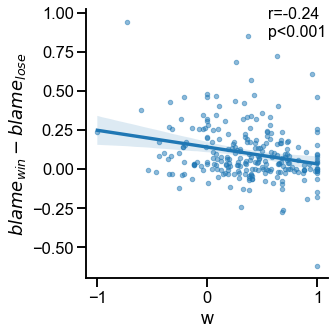

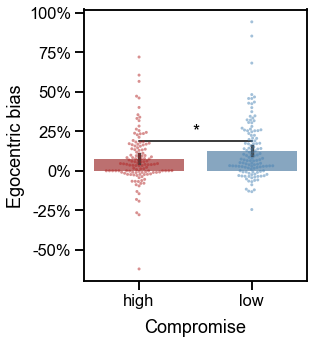

In [77]:
sns.set_context('talk')
compromise_colors = ['firebrick', 'steelblue'] #high, los

#use theta, w
t = df_group.query('step_rt<8 and selfBlame>-1').groupby(['subID', 'room', 'attack'], as_index=False)['selfBlame'].mean()
t = pd.merge(t.query('attack==False'), t.query('attack==True'), on=['subID', 'room'])
t['blame_diff'] = t['selfBlame_x'] - t['selfBlame_y'] #attack_false - attack_win
merged = pd.merge(params_df, t)
print(f"{len(merged)} subjects")

# get riskyiness within dyad through theta
merged = pd.merge(merged.groupby(['room'], as_index=False)['theta'].mean().rename({'theta':'mean_theta'}, axis=1), 
                  merged, how='right')
merged['risky_wpair'] = merged.apply(lambda x:'higher' if x['theta']>x['mean_theta'] else 'lower', axis=1)

#flip for risk-prone subjects: attack_false - attack_true
# merged['blame_diff'] = merged.apply(lambda x: -x['blame_diff'] if x['order']=='risk-prone' else x['blame_diff'], axis=1)
sns.lmplot(data = merged, x='w', y='blame_diff', scatter_kws={"s": 20, 'alpha':0.5})
plt.ylabel('$blame_{win} - blame_{lose}$')

r, p = ss.pearsonr(merged['w'], merged['blame_diff'])
p_txt = f"p={p:.3f}" if p>=0.001 else "p<0.001"
plt.annotate(f'r={round(r, 2)}\n{p_txt}', xy=(0.75, 0.9), xycoords='axes fraction', fontsize=16)

# save
plt.tight_layout()
if save:
    plt.savefig(f'../paper_figs/{folder}/correlation_w_bias_{folder}.png', 
            bbox_inches='tight', dpi=200)


fig, ax = plt.subplots(1, 1, figsize=(4, 5))
median_w = np.median(params_df['w'])
print(f"median w: {median_w}")
merged['compromise'] = merged['w'].apply(lambda x: 'high' if x>= median_w else 'low')
sns.barplot(data=merged, x='compromise', y='blame_diff', 
            palette=compromise_colors, order=['high', 'low'], 
            alpha=0.7
            )
sns.swarmplot(data=merged, x='compromise', y='blame_diff', 
            palette=compromise_colors, order=['high', 'low'], 
            alpha=0.5, s=3
            )
plt.ylabel('Egocentric bias')
plt.xlabel('Compromise', labelpad=10)
# plt.ylabel('$mean (credit - blame)$')
# plt.ylim([0, 0.21])
# ax.set_ylim([-0.35, 0.75])
ax.set_yticklabels(['{:.0f}%'.format(x*100) for x in ax.get_yticks()])



# Perform a t-test to compare the two groups
group_low = merged[merged['compromise'] == 'high']['blame_diff']
group_high = merged[merged['compromise'] == 'low']['blame_diff']
t_stat, p_value = ss.ttest_ind(group_low, group_high)
print(f"t = {t_stat}, p = {p_value}")
# Annotate the plot with significance if p-value < 0.05
sig = get_sig(p_value)
plt.text(0.5, 0.19, sig, ha='center', va='bottom')
plt.plot([0, 0, 1, 1], [0.19, 0.19, 0.19, 0.19], lw=1.5, color='black')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

lower vs. higher: t-test independent samples, P_val:4.913e-01 t=-6.893e-01


(<Axes: xlabel='risky_wpair', ylabel='w'>,
 [<statannotations.Annotation.Annotation at 0x7fe7c1ebaa30>])

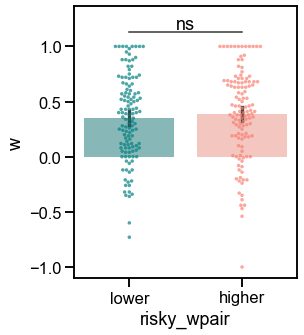

In [78]:
#compare w between risky and risk-averse
fig, ax= plt.subplots(1, 1, figsize=(4, 5))
merged['theta_wpair'] = merged.apply(lambda x: 'higher' if x['theta'] >x['mean_theta'] else 'lower', axis=1)
sns.swarmplot(data=merged, x='risky_wpair', y='w',
            alpha=0.7, s=3.5, palette=risk_colors)
sns.barplot(data=merged, x='risky_wpair', y='w', 
            alpha=0.5, palette=risk_colors)
pairs = [("higher", "lower")]
annotator = Annotator(ax, pairs, data=merged,  x='risky_wpair', y='w')
#set configurations and apply
annotator.configure(test='t-test_ind', hide_non_significant=False,
                    # comparisons_correction="bonferroni", 
                    text_format='star', loc='inside', 
                    line_height =0, text_offset=-1)#for style
annotator.apply_and_annotate()




                                   Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  selfBlame
No. Observations:                    3661                     Method:                              REML     
No. Groups:                          250                      Scale:                               0.0199   
Min. group size:                     6                        Log-Likelihood:                      1364.1012
Max. group size:                     24                       Converged:                           Yes      
Mean group size:                     14.6                                                                   
------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------

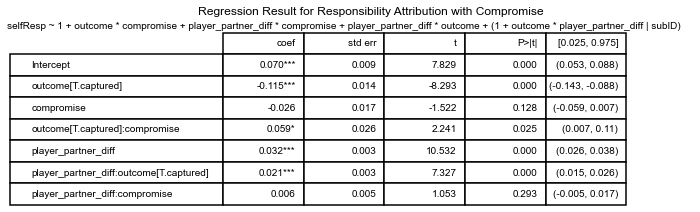

In [79]:
# d['outcome'] = d['attack'].apply(lambda x: 'lose' if x ==True else 'win')
# separate by compromise
median_w = np.median(params_df['w'])

high_w = params_df.query('w>@median_w')['subID'].unique()
d = df_group.query('selfBlame>-1').groupby(['subID', 'attack', 'player_partner_diff'], 
                                            as_index=False)['selfBlame'].mean()
d['compromise'] = d['subID'].apply(lambda x: "high" if x in high_w else "low")
d = pd.merge(d, params_df[['subID', 'w']])

d['outcome'] = d['attack'].apply(lambda x: 'harvest' if x==False else 'captured').astype('category')
d['outcome'] = d['outcome'].cat.reorder_categories(['harvest', 'captured'], ordered=True)

if np.min(d['selfBlame']) ==0:
    d['selfBlame'] = d['selfBlame'] - 0.5
# d['compromise2'] = d['compromise'].apply(lambda x: 1 if x=='low' else 0)
# model = smf.mixedlm(formula='selfBlame ~ outcome * compromise + player_partner_diff * compromise + player_partner_diff * outcome', 
#                     data=d, groups = d['subID'],
#                     re_formula="~ outcome + player_partner_diff + player_partner_diff * outcome"
#                     )
d = d.drop({'compromise'}, axis=1).rename({'w':'compromise'}, axis=1)
# d['selfBlame'] =d.apply(lambda row: 1-row['selfBlame'] if row['attack']==True else row['selfBlame'], axis=1) #rescale to -1 to 1
result = smf.mixedlm(formula='selfBlame ~ outcome * compromise + player_partner_diff * compromise + player_partner_diff * outcome', 
                    data=d, groups = d['subID'],
                    re_formula="~ player_partner_diff * outcome"
                    ).fit()
# model = smf.mixedlm(formula='selfBlame ~ player_partner_diff * compromise* outcome', 
#                     data=d, groups = d['subID'],
#                     re_formula="~ player_partner_diff * compromise * outcome"
#                     )
# result = model.fit()
print(result.summary())

with open(f'../model_fits/regs/trial_level_selfBlame_compromise_{folder}.txt', "w") as f:
    f.write(result.summary().as_text())

blame_formula = 'selfResp ~ 1 + outcome * compromise + player_partner_diff * compromise + player_partner_diff * outcome + (1 + outcome * player_partner_diff | subID)'
title = "Regression Result for Responsibility Attribution with Compromise"
save_reg_to_table(result , 7, blame_formula, title, folder)

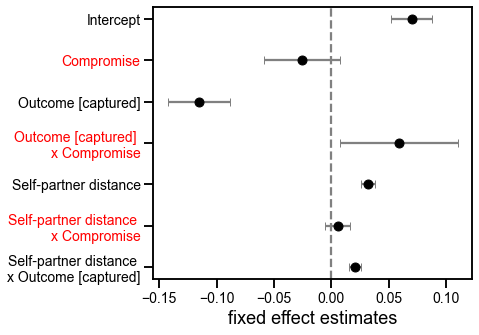

In [80]:


# Extract fixed effects and confidence intervals
fe_params = result.fe_params
ci = result.conf_int()
ci.columns = ['lower', 'upper']

# Combine into a single DataFrame
ci['estimate'] = fe_params
ci = ci.reset_index().rename(columns={'index': 'term'})

# Sort terms (optional, for cleaner plotting)
ci = ci.sort_values(by='term', ascending=False).dropna()
label_map = {
    'Intercept': 'Intercept',
    'outcome[T.captured]': 'Outcome [captured]',
    'compromise': 'Compromise',
    'player_partner_diff': 'Self-partner distance',
    'outcome[T.captured]:compromise': 'Outcome [captured] \nx Compromise',
    'player_partner_diff:compromise': 'Self-partner distance \nx Compromise',
    'player_partner_diff:outcome[T.captured]': 'Self-partner distance \nx Outcome [captured]',
}
ci['term_pretty'] = ci['term'].map(label_map)
# Plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plt.errorbar(
    x=ci['estimate'],
    y=ci['term_pretty'],
    xerr=[ci['estimate'] - ci['lower'], ci['upper'] - ci['estimate']],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=4
)
plt.axvline(x=0, color='gray', linestyle='--')
plt.xlabel('fixed effect estimates')
# plt.ylabel('Term')
for tick_label in ax.get_yticklabels():
    if tick_label.get_text() in ['Outcome [captured] \nx Compromise','Compromise', 'Self-partner distance \nx Compromise']:
        tick_label.set_color('red')

plt.tick_params(labelsize=14) #axis='y', 
# plt.title('Fixed Effects with 95% Confidence Intervals')
plt.tight_layout()
if save:
    plt.savefig(f'../paper_figs/{folder}/blame_betas_compromise_{folder}.png', 
            bbox_inches='tight', dpi=200)
plt.show()



In [81]:
# Convert random effects to DataFrame
random_effects = result.random_effects
betas_df = pd.DataFrame.from_dict(random_effects, orient='index')
betas_df.reset_index(inplace=True)
betas_df.rename(columns={'index': 'subID'}, inplace=True)

# Add fixed effects to get subject-level total effects
for col in result.fe_params.index:
    if col in betas_df.columns:
        betas_df[col] = betas_df[col] + result.fe_params[col]

betas_df['intercept'] = betas_df['Group'] + result.fe_params['Intercept']

betas_df['group'] = betas_df['subID'].apply(lambda x: "high" if x in high_w else "low")

In [82]:
pair_params = pd.merge(df_group[['subID', 'room', 'playerID']].drop_duplicates(), params_df)
pair_params['partner_w'] = pair_params.groupby('room')['w'].transform(
    lambda x: x.iloc[::-1].values
)
pair_params = pd.merge(pair_params, get_ego_bias(df_group, groupby_cols=['subID']))
pair_params = pd.merge(pair_params, df_group.groupby(['subID'], as_index=False)['player_partner_diff'].mean())
pair_params['player_partner_diff'] = np.abs(pair_params['player_partner_diff'])

pair_params.head()


,subID,room,playerID,alpha,theta,gamma,w,nll_idv,nll_grp,nll,partner_w,selfBlame_lose,n_trials_lose,selfBlame_win,n_trials_win,ego_bias,player_partner_diff
0,0,1,0,1.00,0.68,0.80,0.66,181.312500,59.692244,241.004744,1.00,0.615385,13,0.595745,47,-0.019640,0.483333
1,1,1,1,0.10,0.69,1.00,1.00,280.492630,49.152404,329.645035,0.66,0.442308,13,0.500000,46,0.057692,0.483333
2,2,2,0,1.00,0.88,0.84,0.68,206.745001,69.087576,275.832577,-0.22,0.583333,18,0.452381,42,-0.130952,0.466667
3,3,2,1,0.68,0.84,0.86,-0.22,249.830566,100.305382,350.135948,0.68,0.485294,17,0.625000,42,0.139706,0.466667
4,4,3,0,0.79,0.51,0.68,0.48,171.049067,118.057613,289.106680,-0.24,0.414062,32,0.544643,28,0.130580,2.533333


                            OLS Regression Results                            
Dep. Variable:               ego_bias   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     7.858
Date:                Thu, 07 May 2026   Prob (F-statistic):           0.000492
Time:                        21:17:54   Log-Likelihood:                 85.385
No. Observations:                 250   AIC:                            -164.8
Df Residuals:                     247   BIC:                            -154.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1429      0.017      8.378      0.0

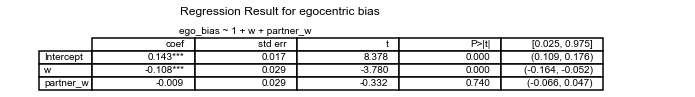

In [83]:
model = smf.ols('ego_bias ~ w + partner_w', data=pair_params).fit()
print(model.summary())

with open(f'../model_fits/regs/egobias_w_partnerw_{folder}.txt', "w") as f:
    f.write(reward_model .summary().as_text())

blame_formula = 'ego_bias ~ 1 + w + partner_w'
title = "Regression Result for egocentric bias"
save_reg_to_table(model, 4, blame_formula, title, folder)

### partial correlation controlling for player_partner_diff

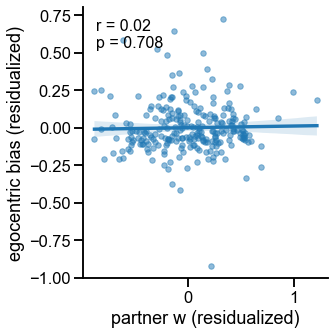

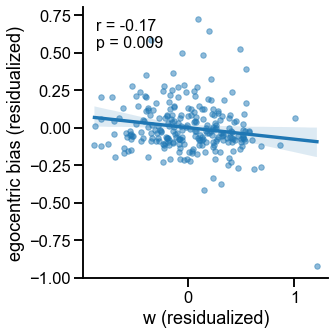

In [84]:
from myutil import partial_corr_manual

# controlling for player_partner_diff, ego_bias is not correlated with partner w
r, p = partial_corr_manual(pair_params, x='ego_bias', y='partner_w', covars=['player_partner_diff'], 
                           xname='egocentric bias', yname='partner w', plot=True, folder=folder)
# print(f"r = {r:.3f}, p = {p:.3f}")

# controlling for player_partner_diff, ego_bias is still correlated with w
r, p = partial_corr_manual(pair_params, x='ego_bias', y='w', covars=['player_partner_diff'], 
                            xname='egocentric bias', yname='w', plot=True, folder=folder)

# print(f"r = {r:.3f}, p = {p:.3f}")

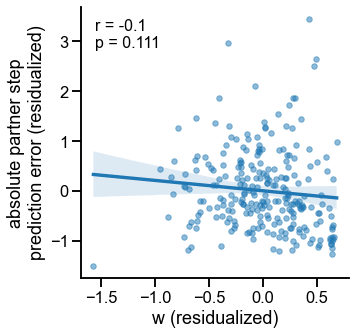

In [85]:
d = pd.merge(params_df, df_group.query('step_rt<8 and prediction>0').groupby(['subID'], as_index=False)[['player_partner_diff', 'abs_pred_error', 'selfBlame']].mean())
r, p = partial_corr_manual(d, y='w', x='abs_pred_error', covars=['player_partner_diff'], 
                            yname = 'w', xname='absolute partner step\nprediction error', 
                            plot=True, folder=folder)

(-0.06809335331845397, 0.2834954753266644)

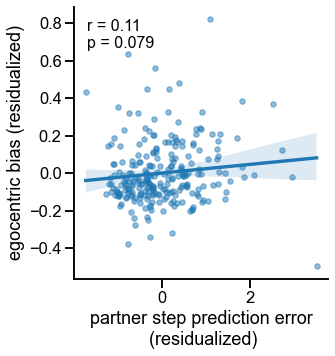

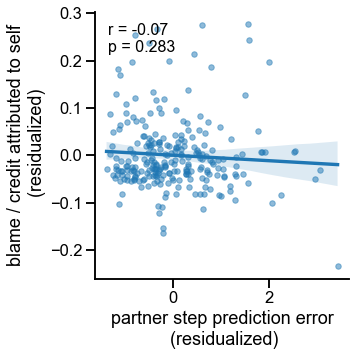

In [86]:
d2 = df_group.query('prediction>0')
d2 = (
    (d2['prediction'] - d2['partnerStep'])
    .abs()
    .groupby(d2['subID'])
    .mean()
    .reset_index(name='pred_error')
)
d = pd.merge(df_group.query('step_rt<8').groupby(['subID'])['player_partner_diff'].mean().reset_index(), 
                            get_ego_bias(df_group, groupby_cols=['subID'])[['subID', 'ego_bias']])
d = pd.merge(d, d2)
# sns.regplot(data = d, x ='ego_bias', y= 'pred_error')
# print(ss.pearsonr(d['ego_bias'], d['pred_error']))

# if save the plot, input folder
partial_corr_manual(d, 'ego_bias', 'pred_error', 'player_partner_diff', plot=True, folder=folder, 
                    yname='partner step prediction error\n', xname='egocentric bias')


# no correlation between blame (agency) and prediction error
d = df_group.query('selfBlame>-1').groupby(['subID'])[['player_partner_diff', 'selfBlame']].mean().reset_index()
d2 = (
    (df_group['prediction'] - df_group['partnerStep'])
    .abs()
    .groupby(df_group['subID'])
    .mean()
    .reset_index(name='pred_error')
)
d = pd.merge(d, d2)
# sns.regplot(data = d, x ='ego_bias', y= 'pred_error')
# print(ss.pearsonr(d['ego_bias'], d['pred_error']))

# if save the plot, input folder
partial_corr_manual(d, 'selfBlame', 'pred_error', 'player_partner_diff', plot=True, folder='', 
                    yname='partner step prediction error\n', xname='blame / credit attributed to self\n')           

# Raw data distribution 

1.3083333333333333 [0.9    1.9625]


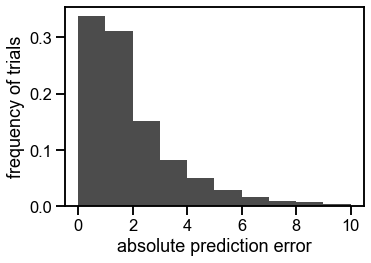

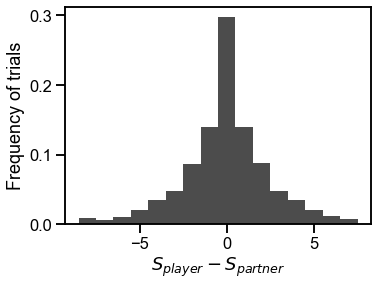

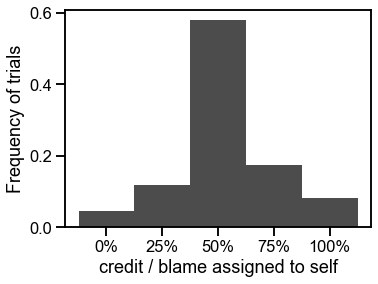

In [87]:
#distribution of prediction error
plt.figure(figsize=(5.5, 4))
plt.hist(df_group['abs_pred_error'], color='black', alpha=0.7, density=True)
plt.xlabel('absolute prediction error')
plt.ylabel('frequency of trials')

d = df_group.groupby('subID')['abs_pred_error'].mean().reset_index() 
print(np.median(d['abs_pred_error']), np.percentile(d['abs_pred_error'], [25, 75]))


if save:
    plt.tight_layout()
    plt.savefig(f'../paper_figs/{folder}/pred_error_{folder}.png', 
            bbox_inches='tight', dpi=200)



#distribution of player partner difference
plt.figure(figsize=(5.5, 4))
plt.hist(df_group['player_partner_diff'], bins=np.arange(-8, 9)-0.5, density=True, 
         color='black', alpha=0.7)
plt.ylabel('Frequency of trials')
plt.xlabel('$S_{player} - S_{partner}$')
if save: 
    plt.savefig(f'../paper_figs/{folder}/ppd_dist_{folder}.png', bbox_inches='tight', dpi=200)



#distribution of selfBlame
plt.figure(figsize=(5.5, 4))
plt.hist(df_group.query('selfBlame!=-1')['selfBlame'], bins=np.arange(0, 1.2, 0.2), density=True, 
         color='black', alpha=0.7)
plt.ylabel('Frequency of trials')
plt.xticks(np.arange(0.1, 1.1, 0.2), ['0%', '25%', '50%', '75%', '100%'])
plt.yticks(np.arange(0, 3.5), np.arange(0, 3.5)/5)
plt.xlabel('credit / blame assigned to self')
if save:
    plt.savefig(f'../paper_figs/{folder}/blame_dist_{folder}.png', bbox_inches='tight', dpi=200)
# d= df_group.query('selfBlame!=-1').groupby(['subID', 'selfBlame'], as_index=False)['trial'].count()
# sns.boxplot(data=d, x='selfBlame', y='trial')

### control for learning

In [88]:
# df_idv.query('num_encounter>60')['subID'].unique()

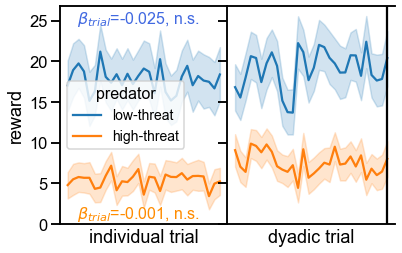

In [89]:
# control for learning
yname = 'reward' # choice or reward
if yname == 'reward':
    df_group['avgMoney'] = df_group['jointMoney'] / 2
    yname2 = 'avgMoney'
elif yname == 'choice':
    yname2 = 'playerStep'


model_idv = smf.ols(
    f"{yname} ~ num_encounter * C(predator)",
    data=df_idv.query("num_encounter > 30 and num_encounter<60")
).fit()

def simple_slope_idv(model, predator):
    names = model.params.index.tolist()
    L = np.zeros(len(names))

    def add(term):
        if term in names:
            L[names.index(term)] += 1

    add("num_encounter")

    if predator == "low-threat":
        add("num_encounter:C(predator)[T.low-threat]")

    test = model.t_test(L)
    beta = float(test.effect)
    p = float(test.pvalue)
    return beta, p

annotations_idv = []

for predator in ["low-threat", "high-threat"]:
    beta, p = simple_slope_idv(model_idv, predator)
    annotations_idv.append({
        "predator": predator,
        "beta": beta,
        "p": p,
        "label": f"$\\beta_{{trial}}$={beta:.3f}, {get_sig(p)}"
    })


fig, axes = plt.subplots(1, 2, sharey=True)
fig.subplots_adjust(wspace=0)  # Remove gap between subplots

# Plot individual (left subplot)
sns.lineplot(
    data=df_idv.query('num_encounter > 30 and num_encounter < 60'),
    x='num_encounter', y=yname,
    hue='predator', hue_order=['low-threat', 'high-threat'],
    ax=axes[0]
)

# Plot group (right subplot)
sns.lineplot(
    data=df_group,
    x='trial', y=yname2,
    hue='predator', hue_order=['low-threat', 'high-threat'],
    ax=axes[1],
    legend=False
)

# Formatting
for ax in axes:
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.spines['right'].set_visible(False)


axes[1].axvline(x=30, color='black', ls='-')  # adjust if needed
axes[0].legend(fontsize=14, loc='center left', title='predator', title_fontsize=16)
axes[0].set_ylabel(yname)
axes[0].set_xlabel('individual trial')
axes[1].set_xlabel('dyadic trial')
plt.ylim(bottom=0)


axes[0].annotate(
    annotations_idv[0]["label"],
    xy=(0.1, 0.925),
    xycoords="axes fraction",
    fontsize=16,
    color="royalblue"
)

axes[0].annotate(
    annotations_idv[1]["label"],
    xy=(0.1, 0.025),
    xycoords="axes fraction",
    fontsize=16,
    color="darkorange"
)

if save:
    plt.savefig(f'../paper_figs/{folder}/{yname}_by_trial_{folder}.png', 
            bbox_inches='tight', dpi=200)

# calculate social reward

In [90]:
social_reward = df_group.copy()
social_reward['partner_assigned_reward'] = (1 - social_reward['partnerBlame']) * social_reward['jointMoney']
social_reward['self_assigned_reward'] = social_reward['selfBlame'] * social_reward['jointMoney']
## swap blame for attack
social_reward['partnerBlame'] = social_reward.apply(lambda row: row['partnerBlame'] if row['attack']==0 else 1-row['partnerBlame'], axis=1)
social_reward['selfBlame'] = social_reward.apply(lambda row: row['selfBlame'] if row['attack']==0 else 1-row['selfBlame'], axis=1)

social_reward_g = pd.merge(social_reward.query('selfBlame>-1 and selfBlame<2').groupby(['subID', 'room'], as_index=False)[['self_assigned_reward', 'selfBlame']].mean(),
                         social_reward.query('partnerBlame>-1 and partnerBlame<2').groupby(['subID', 'room'], as_index=False)[['partner_assigned_reward', 'partnerBlame']].mean())
social_reward_g = pd.merge(social_reward_g, params_df)
social_reward_g['partnerBlame'] = 1 - social_reward_g['partnerBlame']
social_reward_g = pd.merge(social_reward_g, social_reward_g.groupby(['room'], as_index=False)['theta'].mean().rename({'theta':'theta_wpair'}, axis=1),
                         how='left')
social_reward_g['theta_wpair'] = social_reward_g.apply(lambda row: 'higher' if row['theta'] >row['theta_wpair'] else 'lower', axis=1)
social_reward_g['compromise'] = social_reward_g.apply(lambda row: 'high' if row['w']>np.median(social_reward_g['w']) else 'low', axis=1)
print(len(social_reward_g))

250


0.13854270504887428 0.02851358371415675
-0.22643448624334267 0.0003070329353489099


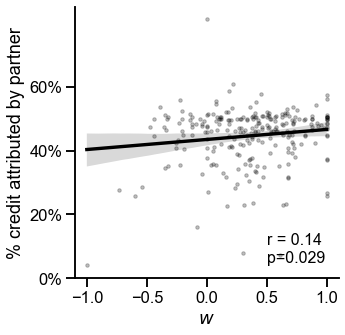

<Figure size 432x288 with 0 Axes>

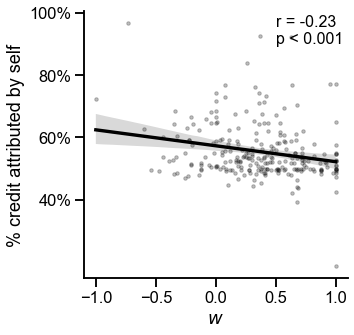

In [91]:
sns.lmplot(data = social_reward_g, x='w', y='partnerBlame', 
           scatter_kws={'s':12, 'alpha':0.25, 'color':'black'}, line_kws={'color':'black'})
r,p = ss.pearsonr(social_reward_g['partnerBlame'], social_reward_g['w'])
print(r, p)

p = f"p={round(p, 3)}" if p>=0.001 else "p < 0.001"
plt.annotate(f"r = {round(r, 2)}\n{p}", xy=(0.5, 0.05), fontsize=16)
plt.ylabel('% credit attributed by partner')
plt.yticks([0, 0.2, 0.4, 0.6], ['0%', '20%', '40%', '60%'])
plt.xlabel('$w$')
# sns.swarmplot(data = social_reward_g, x='compromise', y='partner_assigned_reward')
# sns.barplot(data = social_reward_g, x='compromise', y='partner_assigned_reward')
# print(ss.ttest_ind(social_reward_g.query('compromise =="high"')['partner_assigned_reward'], 
#                    social_reward_g.query('compromise =="low"')['partner_assigned_reward']))
if save:
    plt.savefig(f'../paper_figs/{folder}/partnerBlame_w_{folder}.png', 
                bbox_inches='tight', dpi=200)

plt.figure()
sns.lmplot(data = social_reward_g, x='w', y='selfBlame',
           scatter_kws={'s':12, 'alpha':0.25, 'color':'black'}, line_kws={'color':'black'})
r, p = ss.pearsonr(social_reward_g['selfBlame'], social_reward_g['w'])
print(r, p)

p = f"p={round(p, 3)}" if p>=0.001 else "p < 0.001"
plt.annotate(f"r = {round(r, 2)}\n{p}", xy=(0.5, 0.9), fontsize=16)
plt.ylabel('% credit attributed by self')
plt.yticks([0.4, 0.6, 0.8, 1], ['40%', '60%', '80%', '100%'])
plt.xlabel('$w$')
if save:
    plt.savefig(f'../paper_figs/{folder}/selfBlame_w_{folder}.png', 
                bbox_inches='tight', dpi=200)
# sns.swarmplot(data = social_reward, x='compromise', y='self_assigned_reward')
# sns.barplot(data = social_reward, x='compromise', y='self_assigned_reward')
# print(ss.ttest_ind(social_reward.query('compromise =="high"')['self_assigned_reward'], 
#                    social_reward.query('compromise =="low"')['self_assigned_reward']))

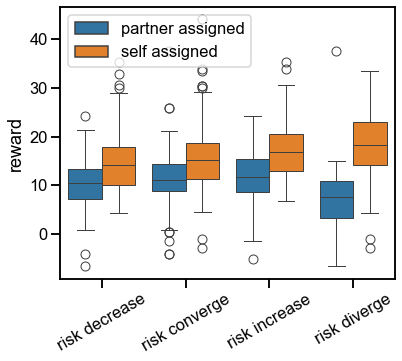

In [92]:

# social_reward_g2 = pd.merge(social_reward.query('selfBlame>-1').groupby(['subID', 'room', 'predatorType'], as_index=False)['self_assigned_reward'].mean(),
#                          social_reward.query('partnerBlame>-1').groupby(['subID', 'room', 'predatorType'], as_index=False)['partner_assigned_reward'].mean())
social_reward_g2= pd.merge(social_reward_g, collapsed_g[['room', 'predatorType', 'cluster']])

# sns.barplot(data=social_reward_g, x='cluster', y='partner_assigned_reward')
# plt.figure()
# sns.barplot(data=social_reward_g, x='cluster', y='self_assigned_reward')

# Reshape to long format
df_long = social_reward_g2.melt(
    id_vars=['cluster'],
    value_vars=['partner_assigned_reward', 'self_assigned_reward'],
    var_name='reward_type',
    value_name='reward'
)
df_long= df_long.replace({'partner_assigned_reward':'partner assigned', 'self_assigned_reward':'self assigned'})
# Plot with hue
plt.figure(figsize=(6,5))
# myswarm(data=df_long, x='cluster', y='reward', hue='reward_type', dodge=True, legend=False)
# mybar(data=df_long, x='cluster', y='reward', hue='reward_type')
sns.boxplot(data=df_long, x='cluster', y='reward', hue='reward_type')

# plt.ylabel("Assigned reward")
plt.xlabel("")
plt.xticks(rotation=30)
plt.legend(loc='upper left')
plt.show()


Text(0.5, 0, '')

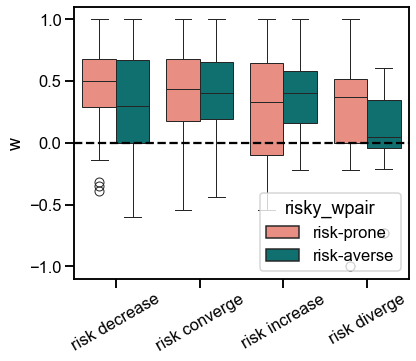

In [93]:
social_reward_g2 = pd.merge(social_reward_g2, group_stat)
social_reward_g2 = pd.merge(social_reward_g2, params_df)
plt.figure(figsize=(6,5))
# mybar(data = social_reward_g2, x='cluster', y='w', hue='risky_wpair')
# myswarm(data = social_reward_g2, x='cluster', y='w', hue='risky_wpair', dodge=True, legend=False)
sns.boxplot(data = social_reward_g2, x='cluster', y='w', hue='risky_wpair', palette=risk_palette)
plt.axhline(0, ls='--', color='black')
plt.xticks(rotation=30)
plt.xlabel("")

# For rep2 only

In [95]:
# Data processing for individual and group foraging
try:
    #get  post individual choice
    gi2 = df_idv2.groupby(['subID', 'predatorType'], as_index=False)[['choice', 'reward']].mean()
    gi2 = gi2.rename({'choice':'choice_post', 'reward':'reward_post'}, axis=1)

    # get group choice
    g_new = pd.merge(gi2, group_stat_filtered[['room', 'risky_wpair', 'predatorType', 'subID', 'group', 'jointMoney', 'individual', 'reward']])
except NameError:
    print("data doesn't exist")

data doesn't exist


TtestResult(statistic=3.8210259141567344, pvalue=0.0001766367745014476, df=203)
Cohen's d for risk-prone: -0.2675253244074299
TtestResult(statistic=2.057451228232523, pvalue=0.04090845254183863, df=205)
Cohen's d for risk-averse: 0.14334941960044373


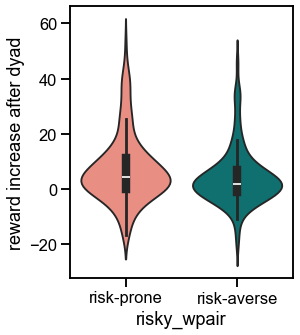

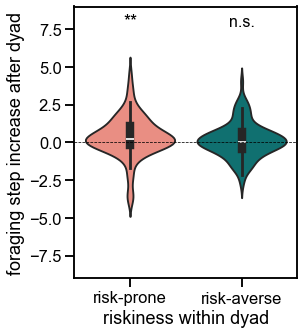

In [ ]:
# #compare money increase between risky and risk-averse individuals
g_new['reward_inc'] = g_new['reward_post'] - g_new['jointMoney'] / 2
g_new['step_inc'] = g_new['choice_post'] - g_new['group']

plt.figure(figsize=(4, 5))
sns.violinplot(data=g_new, y='reward_inc', x='risky_wpair', palette=risk_palette)
plt.ylabel('reward increase after dyad')

plt.figure(figsize=(4, 5))
sns.violinplot(data=g_new, y='step_inc', x='risky_wpair', palette=risk_palette, 
            # flierprops=dict(markersize=8, alpha=0.7)
            )
plt.xlabel('riskiness within dyad')
plt.ylabel('foraging step increase after dyad')
plt.text(1, 8, "n.s.", ha='center', va='center', fontsize=16) #this is based on regression runned later
plt.text(0, 8, "**", ha='center', va='center', fontsize=18) #this is based on regression runned later
plt.ylim([-9, 9])
plt.axhline(0, color='black', lw=0.75, ls='--')

plt.savefig(f'../paper_figs/{folder}/step_inc_{folder}.png', 
            bbox_inches='tight', dpi=200)


print(ss.ttest_1samp(g_new.query('risky_wpair=="risk-prone"')['step_inc'], 0))
sample =g_new.query('risky_wpair=="risk-prone"')['step_inc']
mean_diff = 0 - np.mean(sample)  # or just np.mean(sample)
std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
cohens_d = mean_diff / std_dev
print(f"Cohen's d for risk-prone: {cohens_d}")


print(ss.ttest_1samp(g_new.query('risky_wpair=="risk-averse"')['step_inc'], 0))
sample =g_new.query('risky_wpair=="risk-averse"')['step_inc']
mean_diff = np.mean(sample) - 0  # or just np.mean(sample)
std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
cohens_d = mean_diff / std_dev
print(f"Cohen's d for risk-averse: {cohens_d}")




TtestResult(statistic=-2.0403229771118196, pvalue=0.04261302267739551, df=203)
Cohen's d for risk-prone: 0.14285118149172085
TtestResult(statistic=6.002375106732473, pvalue=8.705333956829566e-09, df=205)
Cohen's d for risk-averse: 0.4182052901022686


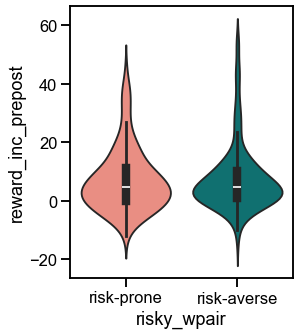

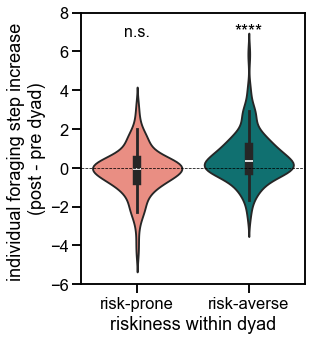

In [ ]:
# #compare money increase between risky and risk-averse individuals
g_new['step_inc_prepost'] = g_new['choice_post'] - g_new['individual']
# g_new['step_inc'] = g_new['choice_post'] - g_new['group']
g_new['reward_inc_prepost'] =g_new['reward_post'] -  g_new['reward']

plt.figure(figsize=(4, 5))
sns.violinplot(data=g_new, y='reward_inc_prepost', x='risky_wpair', palette=risk_palette)


plt.figure(figsize=(4, 5))
sns.violinplot(data=g_new, y='step_inc_prepost', x='risky_wpair', palette=risk_palette, 
            # flierprops=dict(markersize=8, alpha=0.7)
            )

# need to correct for multiple comparison?
plt.xlabel('riskiness within dyad')
plt.ylabel('individual foraging step increase \n(post - pre dyad)')
plt.text(0, 7, "n.s.", ha='center', va='center', fontsize=16) #this is based on regression runned later
plt.text(1, 7, "****", ha='center', va='center', fontsize=18) #this is based on regression runned later
plt.ylim([-6, 8])
plt.axhline(0, color='black', lw=0.75, ls='--')



print(ss.ttest_1samp(g_new.query('risky_wpair=="risk-prone"')['step_inc_prepost'], 0))
sample =g_new.query('risky_wpair=="risk-prone"')['step_inc_prepost']
mean_diff = 0 - np.mean(sample)  # or just np.mean(sample)
std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
cohens_d = mean_diff / std_dev
print(f"Cohen's d for risk-prone: {cohens_d}")


print(ss.ttest_1samp(g_new.query('risky_wpair=="risk-averse"')['step_inc_prepost'], 0))
sample =g_new.query('risky_wpair=="risk-averse"')['step_inc_prepost']
mean_diff = np.mean(sample) - 0  # or just np.mean(sample)
std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
cohens_d = mean_diff / std_dev
print(f"Cohen's d for risk-averse: {cohens_d}")


plt.savefig(f'../paper_figs/{folder}/step_inc_prepost_{folder}.png', 
            bbox_inches='tight', dpi=200)
